In [62]:
ls()

[1] "MIN_LEN"                     "a_legc"                     
 [3] "add.flag"                    "agg_id"                     
 [5] "agg_id_day"                  "amos_peak_calling_function" 
 [7] "ann_colors"                  "atac_mc_day"                
 [9] "atac_mc_day_norm"            "boxplot_vec"                
[11] "clr6"                        "clrmp"                      
[13] "cnis"                        "col_annot"                  
[15] "col_key"                     "cor_mat_ipa"                
[17] "cust_mc_ord_st"              "cust_st_ord"                
[19] "delta_egc_ipc_nsc"           "e13_e17_nna"                
[21] "egc_by_day"                  "egc_by_day_ipc"             
[23] "egc_by_day_n"                "egc_by_day_n_ipc"           
[25] "get_genes_specific_to_mcs"   "get_mc_cc"                  
[27] "hi_var_inds"                 "hvm"                        
[29] "hvm_mean"                    "hvm_nei"                    
[31] "hvmm_dec"                    "hvmm_inc"                   
[33] "i"                           "ins_prc_all"                
[35] "ins_tracks"                  "intervs"                    
[37] "intis_dec"                   "intis_inc"                  
[39] "ipc_mcs"                     "jacc"                       
[41] "legc"                        "m2"                         
[43] "mat_ipa"                     "mc_rna"                     
[45] "mca"                         "mcmd"                       
[47] "mcp"                         "mctnetwork_plot_net_YSh"    
[49] "mctnetwork_plot_propagation" "mm_mctnetwork_plot_net"     
[51] "multintersect"               "multunion"                  
[53] "nsc_mcs"                     "off_diag_inds"              
[55] "plot_color_bar"              "pltmt"                      
[57] "proximal_chromatin_activity" "q10_ins_tracks"             
[59] "rand_hvm"                    "rna_mc_day"                 
[61] "rna_mc_day_norm"             "rowMaxmins"                 
[63] "save_pheatmap_pdf"           "save_pheatmap_png"          
[65] "score_tracks"                "transform_x_to_scale"       
[67] "tss"                         "tss2"                       
[69] "uq10_intervs"                "uq10_intervs_1kb"           
[71] "uq10_minima"                 "uq10_union"                 
[73] "uq10_union_iter"             "vioplot_vec"                
[75] "wd"

In [4]:
wd <- "/net/mraid20/export//tgdata/users/yonshap/proj/mmcortex/"
setwd(wd)

In [5]:
devtools::load_all('~/src/shaman')

# library(IDPmisc)
library(misha)
# library(shaman)
library(tgstat)
library(dplyr)
library(metacell)
library(matrixStats)
gsetroot('/home/aviezerl/mm10')
# mmc_path = '/net//mraid14//export//tgdata//db//tgdb//mm10/trackdb/tracks/mmcortex//tracks'
# setwd(mmc_path)
# day_dirs = dir(mmc_path)
# day_dirs
# setwd(file.path(mmc_path, day_dirs[[1]]))
tss = gintervals.load('intervs.global.tss')

options(gmax.data.size = 1e+9)

clr6 = colorRampPalette(c('yellow', 'blue'))(6)

i Loading shaman
Possible Ensembl SSL connectivity problems detected.
Please see the 'Connection Troubleshooting' section of the biomaRt vignette
vignette('accessing_ensembl', package = 'biomaRt')Error in curl::curl_fetch_memory(url, handle = handle) : 
  SSL peer certificate or SSH remote key was not OK: [uswest.ensembl.org] SSL certificate problem: certificate has expired


building example db...


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'matrixStats'


The following object is masked from 'package:dplyr':

    count




In [6]:
source('./scripts/util.r')

In [7]:
mcmd <- readr::read_tsv('~/raid/proj/mmcortex/BonevCollab/mcmd_pl_cort.tsv')
mcmd <- mcmd[!(mcmd$metacell %in% 602:603),]
cust_st_ord = c('OPCs','Astrocytes','NSC','IPC_cyc', 'IPC', 'iCPN_early','iCPN_late',
                      'CPN_L2-3','CPN_L5_6','iCPN/CfuPN','iCfuPN','SCPN','CthPN')
cust_mc_ord_st = unlist(lapply(cust_st_ord, function(st) setNames(mcmd$metacell[which(mcmd$cell_type == st)[order(mcmd$mean_day[which(mcmd$cell_type == st)])]], 
                                                                  rep(st, length(which(mcmd$cell_type == st))))))

col_key <- tibble::deframe(unique(mcmd[,c('cell_type', 'color')]))
col_key

Rows: 1093 Columns: 11
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (2): cell_type, color
dbl (9): metacell, E13, E14, E15, E16, E17, E18, mean_day, time_bin

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


iCPN_late iCPN/CfuPN iCPN_early        IPC   CPN_L5_6       SCPN     iCfuPN 
 "#CD3700"  "#FF3E96"  "#FA8072"  "#0000CD"  "#9FB6CD"  "#FFA500"  "#87CEFA" 
  CPN_L2-3      CthPN        NSC       OPCs Astrocytes    IPC_cyc 
 "#EED2EE"  "#8B4726"  "#00C5CD"  "#006400"  "#C4658D"  "#C0FF3E"

In [8]:
col_annot <- tibble::column_to_rownames(mcmd[,c('metacell', 'cell_type', 'mean_day')], 'metacell')
# col_annot

In [9]:
ann_colors <- list(cell_type = tibble::deframe(unique(mcmd[,c('cell_type', 'color')])),
                  mean_day = colorRampPalette(c('red', 'orange', 'yellow', 'green', 'blue', 'purple'))(100))

In [10]:
nsc_mcs <- which(mcmd$cell_type == 'NSC')
ipc_mcs <- which(mcmd$cell_type %in% c('IPC', 'IPC_cyc'))

In [11]:
scdb_init('~/raid/proj/mmcortex/scdb', f=T)

initializing scdb to ~/raid/proj/mmcortex/scdb



In [12]:
mc_rna <- scdb_mc('pl_cort')

In [13]:
tss <- tss[tss$geneSymbol %in% rownames(mc_rna@e_gc),]

In [14]:
tss2 <- tss[!duplicated(tss$geneSymbol),]

## ATAC data

In [15]:
# mca <- readRDS('~/raid/proj/mmcortex/output/mcatac/mmcortex_mcatac_feat_peaks.rds')
mca <- readRDS('~/raid/proj/mmcortex/output/mcatac/mmcortex_mcatac_feat_peaks_no_602_603.rds')

In [16]:
mcp <- as.data.frame(dplyr::select(mca@peaks, chrom, start, end, peak_name))

In [17]:
agg_id <- readr::read_csv('~/raid/proj/mmcortex/scatac_data//aggregation_id.csv')
mca@cell_to_metacell$agg_id <- as.numeric(unlist(purrr::map(stringr::str_split(mca@cell_to_metacell$cell_id, '-'), 2)))
agg_id_day <- data.frame(cbind(1:14, rep(12:18, each = 2)))
colnames(agg_id_day) <- c('agg_id', 'day')
mca@cell_to_metacell$day <- agg_id_day$day[mca@cell_to_metacell$agg_id]

atac_mc_day <- table(mca@cell_to_metacell$metacell, mca@cell_to_metacell$day)
atac_mc_day_norm <- atac_mc_day/rowSums(atac_mc_day)
rna_mc_day <- as.matrix(mcmd[,grep('E\\d\\d', colnames(mcmd))])
rna_mc_day_norm <- rna_mc_day/rowSums(rna_mc_day)
nsc_mcs <- which(mcmd$cell_type == 'NSC')
ipc_mcs <- which(mcmd$cell_type %in% c('IPC', 'IPC_cyc'))
egc_by_day <- mca@egc[,nsc_mcs] %*% atac_mc_day_norm[nsc_mcs,]
egc_by_day_n <- t(t(egc_by_day)/colSums(egc_by_day))
colnames(egc_by_day_n) <- paste0('E', colnames(egc_by_day_n))
egc_by_day_ipc <- mca@egc[,ipc_mcs] %*% atac_mc_day_norm[ipc_mcs,]
egc_by_day_n_ipc <- t(t(egc_by_day_ipc)/colSums(egc_by_day_ipc))
colnames(egc_by_day_n_ipc) <- paste0('E', colnames(egc_by_day_n_ipc))
delta_egc_ipc_nsc <- log2(1e-5 + egc_by_day_n_ipc[,tail(colnames(egc_by_day_n_ipc), -1)]) - log2(1e-5 + egc_by_day_n[,head(colnames(egc_by_day_n), -1)])

Rows: 14 Columns: 2
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): sample_name
dbl (1): library_id

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Loading required package: mcATAC

i Parallelization enabled. Using 77 threads.


Attaching package: 'mcATAC'


The following object is masked _by_ '.GlobalEnv':

    mcmd




In [18]:
legc <- log2(1e-5 + mc_rna@e_gc)
a_legc <- log2(1e-5 + t(t(mca@egc)/colSums(mca@egc)))

In [19]:
# ex_tracks = lapply(2:7, function(n) gtrack.ls(glue::glue('(mmcortex).*(E1{n})')))

# names(ex_tracks) = paste0('E', 12:17)

# ex_tracks

# e12_tracks = gtrack.ls('(mmcortex).*(E12)')

# ex_tracks[[1]]

# grep('(.*NSC)\\..*', ex_tracks[[1]],v=T)

#     prefix = stringr::str_extract(ex_tracks[[1]][[1]], '(.*NSC)')
#     contact_tracks = paste0(prefix, c('.rep1', '.rep2'))
# contact_tracks

# sapply(ex_tracks, function(t) {
#     prefix = stringr::str_extract(t[[1]], '(.*NSC)')
#     contact_tracks = paste0(prefix, c('.rep1', '.rep2'))
#     gtrack.2d.create()
# }) 

# e12_tracks

# grep('ins', gtrack.ls('mmcortex'), v=T)

# gtrack.rm(grep('dense_dense', gtrack.ls('mmcortex'), v=T), force = T)

# gdb.reload()

In [20]:
# purrr::walk(ins_tracks, function(x) gtrack.create(track = paste0(x, '_dense'), description = paste0('Dense ', x), expr = x, iterator = 1e+3))
#     gvtrack.create(vtrack = paste0(x, '_prc'), src = x, func = 'global.percentile'))

In [21]:
ins_tracks = grep('dup|E12', tail(grep('ins_250_dense', gtrack.ls('mmcortex'), v=T), -1), inv = T, v=T)

In [22]:
ins_tracks

[1] "mmcortex.tracks.E13_NSC.ins_250_dense"
[2] "mmcortex.tracks.E14_NSC.ins_250_dense"
[3] "mmcortex.tracks.E15_NSC.ins_250_dense"
[4] "mmcortex.tracks.E16_NSC.ins_250_dense"
[5] "mmcortex.tracks.E17_NSC.ins_250_dense"

In [23]:
score_tracks <- grep('dup|E12', grep('^tracks\\.', tail(gtrack.ls('NSC.score'), -1), inv=T, v=T), inv = T, v=T)
score_tracks

[1] "mmcortex.tracks.E13_NSC.score_k100" "mmcortex.tracks.E14_NSC.score_k100"
[3] "mmcortex.tracks.E15_NSC.score_k100" "mmcortex.tracks.E16_NSC.score_k100"
[5] "mmcortex.tracks.E17_NSC.score_k100"

In [22]:
# ins_means_factor= ins_summary['Mean',]/mean(ins_summary['Mean',])
# ins_means_factor

In [23]:
# purrr::walk(ins_tracks, function(x) gvtrack.create(vtrack = paste0(x, '_prc'), src = x, func = 'global.percentile'))

# ins_t_prc = paste0(ins_tracks, '_prc')

# #### ins_t_prc

# ins_prc_all = gextract(ins_t_prc, intervals = .misha$ALLGENOME[[1]], iterator = 1e+3)

In [24]:
q10_ins_tracks <- unlist(plyr::llply(ins_tracks, function(trk) gquantiles(trk,percentiles = 0.05,iterator = 1e+3), .parallel = T))

uq10_intervs <- plyr::llply(seq_along(ins_tracks), function(i) gscreen(expr = glue::glue('{ins_tracks[[i]]} <= {q10_ins_tracks[[i]]}'), intervals = .misha$ALLGENOME[[1]], iterator = 1e+3))

MIN_LEN <- 5e+3

uq10_intervs <- lapply(uq10_intervs, function(x) dplyr::filter(dplyr::mutate(x, len = end - start, diff = c(NA, diff(start))), len >= MIN_LEN))

uq10_intervs_1kb <- plyr::llply(seq_along(uq10_intervs), function(i) gextract(ins_tracks[[i]], intervals = uq10_intervs[[i]], iterator = 1e+3), .parallel = T)

uq10_minima <- plyr::llply(uq10_intervs_1kb, function(x) do.call('rbind', lapply(unique(x[,5]), function(iij) {indsj <- which(x[,5] == iij); x[indsj[which.min(x[indsj,4])],]})), .parallel = T)

uq10_union <- uq10_minima[[1]]

for (i in tail(seq_along(uq10_intervs), -1)) {
    uq10_union <- gintervals.union(uq10_union, uq10_minima[[i]])
}

uq10_union <- dplyr::mutate(uq10_union, len = end - start, diff = c(NA, diff(start))) 
# %>%
                # dplyr::filter(len >= MIN_LEN)

uq10_union <- dplyr::mutate(uq10_union, start = ifelse(len != 1e+3, start-(MIN_LEN - len)/2, start - 2e+3), 
                            end = ifelse(len != 1e+3, end-(MIN_LEN - len)/2, end + 2e+3), len = end - start)

uq10_union <- gintervals.canonic(uq10_union) %>% dplyr:: mutate(len = end - start)

uq10_union_iter <- giterator.intervals(expr = "NA", intervals = uq10_union, iterator = MIN_LEN) %>% 
                            dplyr::mutate(start = start - start%%MIN_LEN, end = end + MIN_LEN - end%%MIN_LEN, len = end - start) %>% 
                    giterator.intervals(expr = "NA", intervals = ., iterator = MIN_LEN) %>% 
                            dplyr::mutate(len = end - start) 

In [25]:
# head(uq10_union)

In [25]:
ins_prc_all <- gextract(ins_tracks, intervals = .misha$ALLGENOME[[1]], iterator = 1e+3)

In [26]:
ins_prc_all$intervalID <- 1:nrow(ins_prc_all)

In [27]:
intervs <- ins_prc_all[,1:3]
intervs$peak_name <- mcATAC::peak_names(intervs, tad_based = F)

In [28]:
mat_ipa <- -1 * as.matrix(subset(ins_prc_all, select = -c(chrom, start, end, intervalID)))

In [29]:
cnis <- stringr::str_extract(colnames(mat_ipa), 'E\\d\\d')

In [30]:
cor_mat_ipa <- tgs_cor(mat_ipa, spearman = T, pairwise.complete.obs = T)

In [31]:
off_diag_inds <- cbind(head(1:nrow(cor_mat_ipa), -1), tail(1:nrow(cor_mat_ipa), -1))

mean(sapply(1:nrow(off_diag_inds), function(i) cor_mat_ipa[off_diag_inds[i,1], off_diag_inds[i,2]]**2))

sd(sapply(1:nrow(off_diag_inds), function(i) cor_mat_ipa[off_diag_inds[i,1], off_diag_inds[i,2]]**2))

[1] 0.96049

[1] 0.01131123

In [32]:
# doMC::registerDoMC(10)
# mat_ipa_sm <- t(plyr::aaply(mat_ipa, 2, zoo::rollmean, 5, na.pad = T))

In [33]:
e13_e17_nna <- which(!is.na(ins_prc_all[,c("mmcortex.tracks.E13_NSC.ins_250_dense")]) & 
                     !is.na(ins_prc_all[,c("mmcortex.tracks.E17_NSC.ins_250_dense")]))

In [34]:
# na_per_interv <- plyr::alply(mat_ipa, 1, function(x) length(which(is.na(x))), .parallel = T)

In [35]:
clrmp <- colorRampPalette(c('yellow', 'blue'))(5)

In [36]:
# plot(0, xlim = c(-2.5,-1.5), ylim = c(0,1), col = 'white')
# ttt <- sapply(seq_along(tail(colnames(mat_ipa), -1)), function(i) plot(ecdf(mat_ipa[,i+1]), add = T, col = clrmp[[i]]))

In [37]:
# mat_ipa <- mat_ipa[na_per_interv < 5,]
mat_ipa <- mat_ipa[e13_e17_nna,]

In [38]:
head(mat_ipa)

,mmcortex.tracks.E13_NSC.ins_250_dense,mmcortex.tracks.E14_NSC.ins_250_dense,mmcortex.tracks.E15_NSC.ins_250_dense,mmcortex.tracks.E16_NSC.ins_250_dense,mmcortex.tracks.E17_NSC.ins_250_dense
3255,1.702644,NaN,1.737362,1.675092,1.690808
3256,1.703340,1.722311,1.726421,1.670206,1.690306
3257,1.701794,1.713386,1.729770,1.662667,1.690762
3258,1.706838,1.720074,1.737296,1.668512,1.703502
3259,1.711458,1.730042,1.748620,1.678911,1.716265
3260,1.711862,1.727896,1.748406,1.685408,1.714697


## Fig S5A

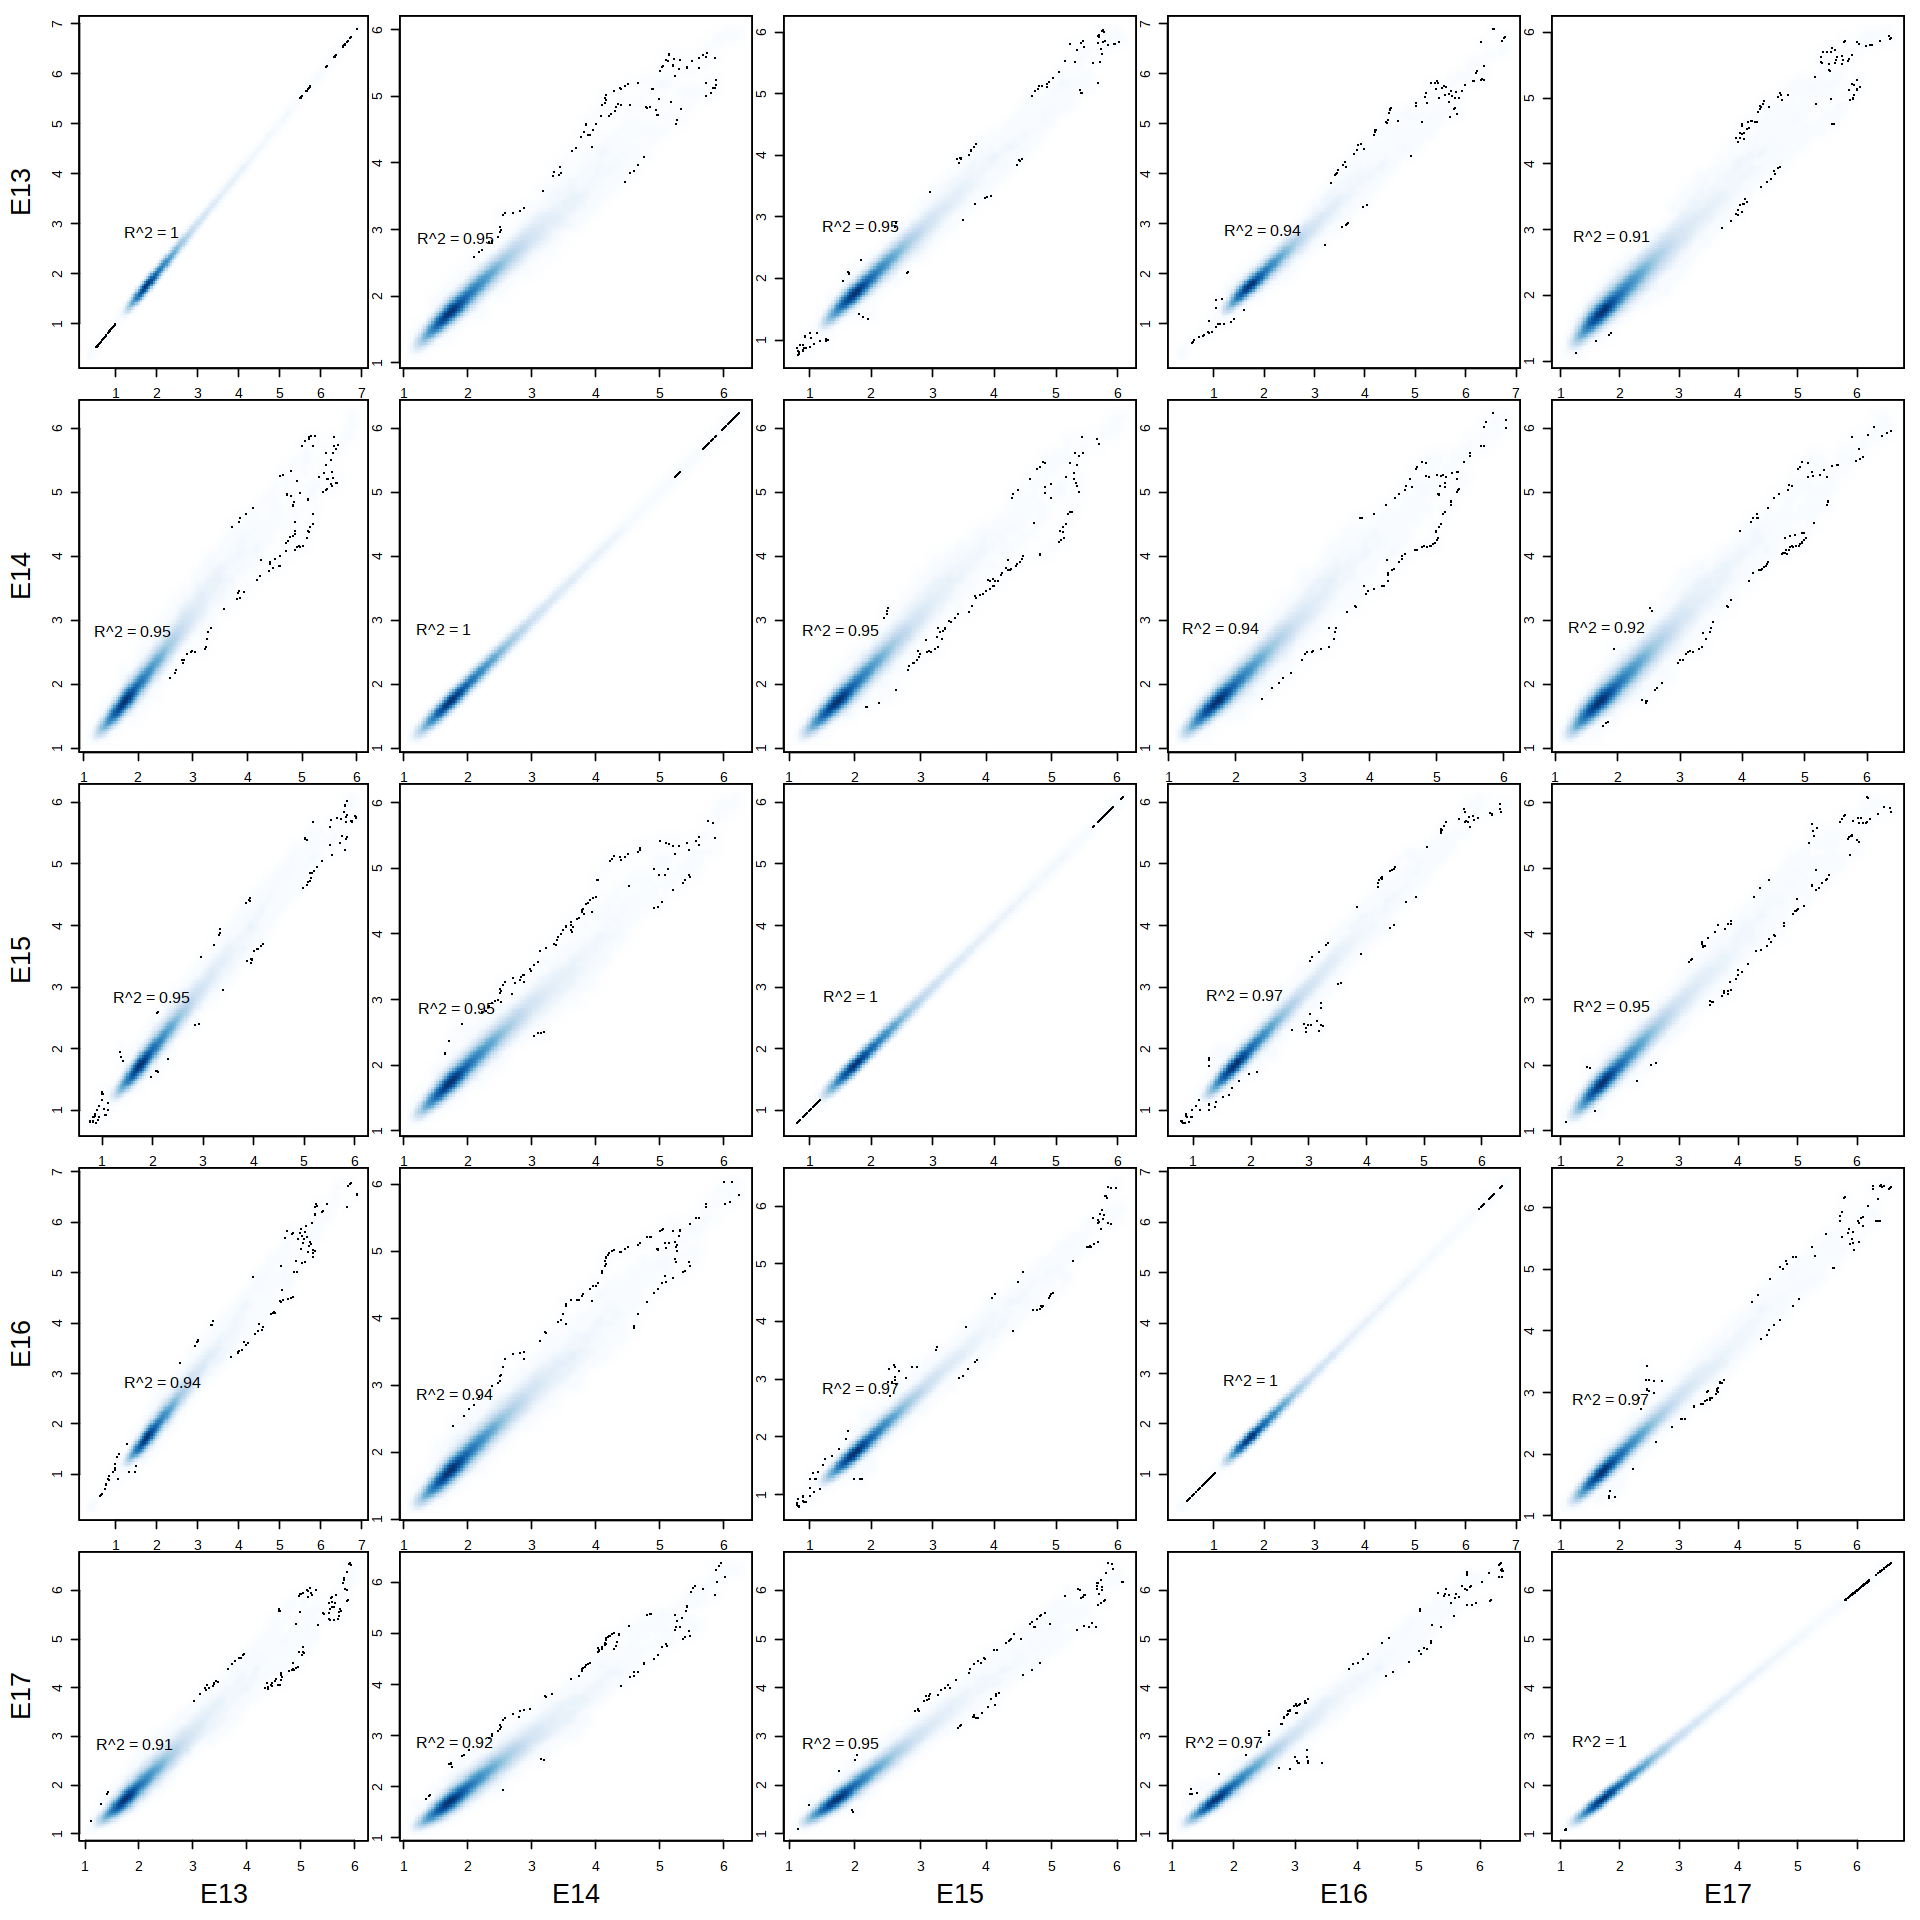

In [31]:
options(repr.plot.width = 16)
options(repr.plot.height = 16)

# png('./output/hic/figs/cor_mat_ipa_by_cni.png', h = 1000, w = 1000)
mari <- c(1,1,1,1)
par(mfrow = c(5,5), mar = mari, cex.lab = 2)
for (cni in colnames(mat_ipa)) {
    for (cnj in colnames(mat_ipa)) {
        if (cnj == head(colnames(mat_ipa), 1)) {ylabi <- stringr::str_extract(cni, 'E\\d\\d'); mari[[2]] <- 5} else {ylabi <- ''; mari[[2]] <- 1}
        if (cni == tail(colnames(mat_ipa), 1)) {xlabi <- stringr::str_extract(cnj, 'E\\d\\d'); mari[[1]] <- 5} else {xlabi <- ''; mari[[1]] <- 1}
        par(mar = mari)
        smoothScatter(mat_ipa[,cnj], mat_ipa[,cni],
                      xlab = xlabi, ylab = ylabi)
        text(quantile(mat_ipa[,cni], 0.0001, na.rm = T), quantile(mat_ipa[,cnj], 0.99, na.rm = T), labels = paste0('R^2 = ', round(cor_mat_ipa[cni,cnj]**2, 2)), cex = 1.2, adj = c(0,0.5))
        
    }
}
# dev.off()

In [39]:
hi_var_inds <- rownames(mat_ipa)[which(mat_ipa[,1] - mat_ipa[,ncol(mat_ipa)] <= -0.35 | 
                    mat_ipa[,1] - mat_ipa[,ncol(mat_ipa)] >= 0.25)]

In [40]:
pltmt <- mat_ipa[hi_var_inds,]

In [41]:
# pltmt <- subset(pltmt, select = -mmcortex.tracks.E14_NSC.ins_250_dense) - rowMeans(pltmt, na.rm = T)
pltmt <- pltmt - rowMeans(pltmt, na.rm = T)

In [42]:
hvm <- gintervals.canonic(intervs[hi_var_inds,]) %>% dplyr::filter(end - start >= 5e+3)

In [43]:
hvm$chrom <- as.character(hvm$chrom)

In [44]:
rand_hvm <- dplyr::sample_n(tbl = giterator.intervals('NA', intervals = .misha$ALLGENOME[[1]], iterator = 5e+3), size = 5e+2)

In [45]:
hvm_nei <- gintervals.neighbors(dplyr::mutate(hvm, intervalID = 1:nrow(hvm)), 
                                dplyr::rename(ins_prc_all, intervalID2 = intervalID), mindist = 0, maxdist = 1, maxneighbors = 1e+6)

In [46]:
# hvm_mean <- tgs_matrix_tapply(t(subset(ins_prc_all[hvm_nei$intervalID2,], select = -c(chrom, start, end, mmcortex.tracks.E14_NSC.ins_250_dense, intervalID))), hvm_nei$intervalID, mean, na.rm = T)
hvm_mean <- -1 * tgs_matrix_tapply(t(subset(ins_prc_all[hvm_nei$intervalID2,], select = -c(chrom, start, end, intervalID))), hvm_nei$intervalID, mean, na.rm = T)

In [47]:
head(hvm_mean)

,mmcortex.tracks.E13_NSC.ins_250_dense,mmcortex.tracks.E14_NSC.ins_250_dense,mmcortex.tracks.E15_NSC.ins_250_dense,mmcortex.tracks.E16_NSC.ins_250_dense,mmcortex.tracks.E17_NSC.ins_250_dense
1,2.228500,2.231649,2.119189,2.033629,1.957074
2,1.840600,1.786038,1.687629,1.687654,1.572675
3,2.538667,2.378602,2.438263,2.310827,2.270248
4,2.141749,2.015060,2.016161,1.955821,1.889341
5,2.338200,2.206212,2.173549,2.128123,2.066744
6,1.886549,2.022350,2.044326,2.084753,2.279808


In [48]:
hvmm_dec <- hvm[which(hvm_mean[,1] - hvm_mean[,ncol(hvm_mean)] > 0),]
hvmm_dec <- hvmm_dec[order(hvm_mean[rownames(hvmm_dec),1] - hvm_mean[rownames(hvmm_dec),ncol(hvm_mean)], decreasing = T),]
hvmm_inc <- hvm[which(hvm_mean[,1] - hvm_mean[,ncol(hvm_mean)] < 0),]
hvmm_inc <- hvmm_inc[order(hvm_mean[rownames(hvmm_inc),1] - hvm_mean[rownames(hvmm_inc),ncol(hvm_mean)], decreasing = F),]

In [49]:
pltmt <- hvm_mean[order(hvm_mean[,1] - hvm_mean[,ncol(hvm_mean)], decreasing = F),]
colnames(pltmt) <- unlist(stringr::str_extract_all(colnames(pltmt), pattern = 'E\\d\\d'))

In [50]:
m2 <- pltmt - rowMeans(pltmt, na.rm = T)

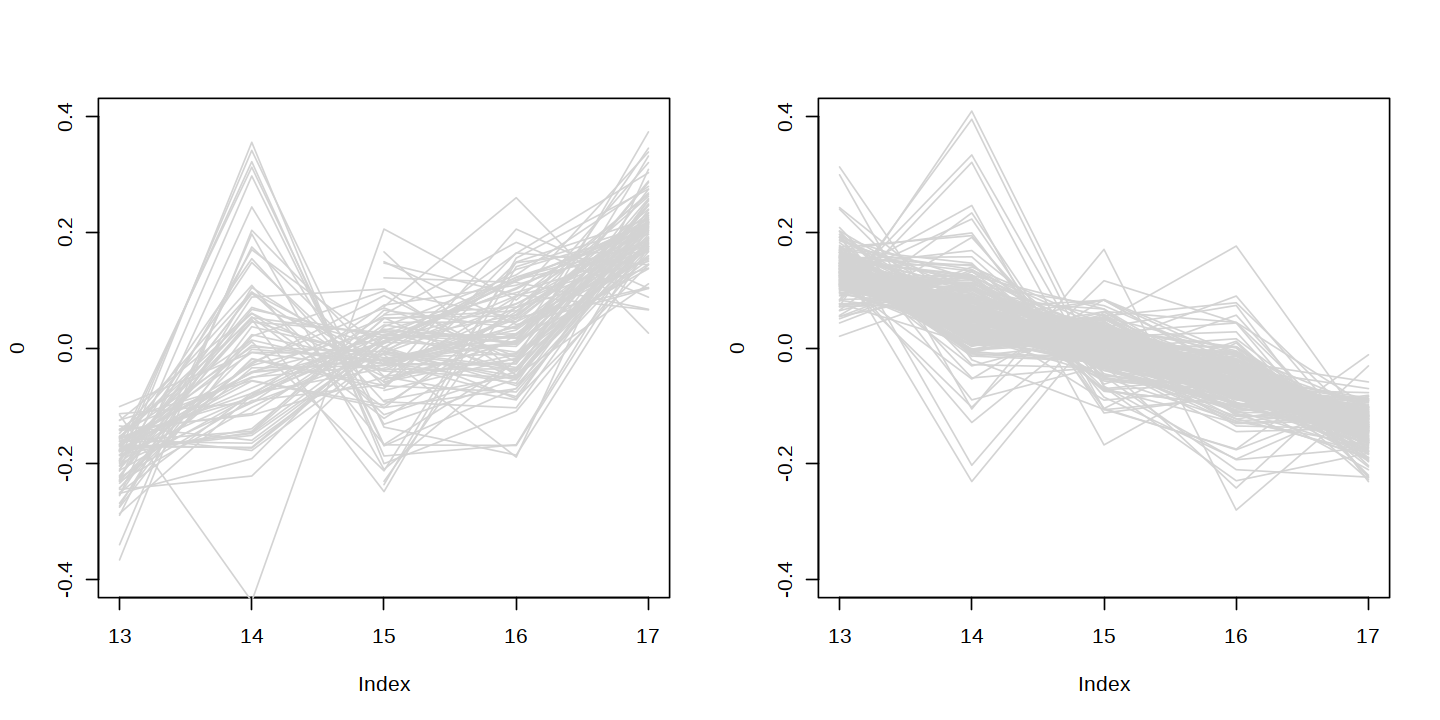

In [234]:
options(repr.plot.width = 12)
options(repr.plot.height = 6)
par(mfrow = c(1,2))
plot(0,col = 'white', xlim = c(13,17), ylim = c(-0.4,0.4))
uuu <- sapply(1:nrow(hvmm_inc), function(i) lines(13:17, m2[i,], col = 'lightgray'))

plot(0,col = 'white', xlim = c(13,17), ylim = c(-0.4,0.4))
uuu <- sapply((nrow(hvmm_inc)+1):nrow(m2), function(i) lines(13:17, m2[i,], col = 'lightgray'))

In [86]:
options(repr.plot.width = 6)
options(repr.plot.height = 8)

## Fig 5A

png 
  2

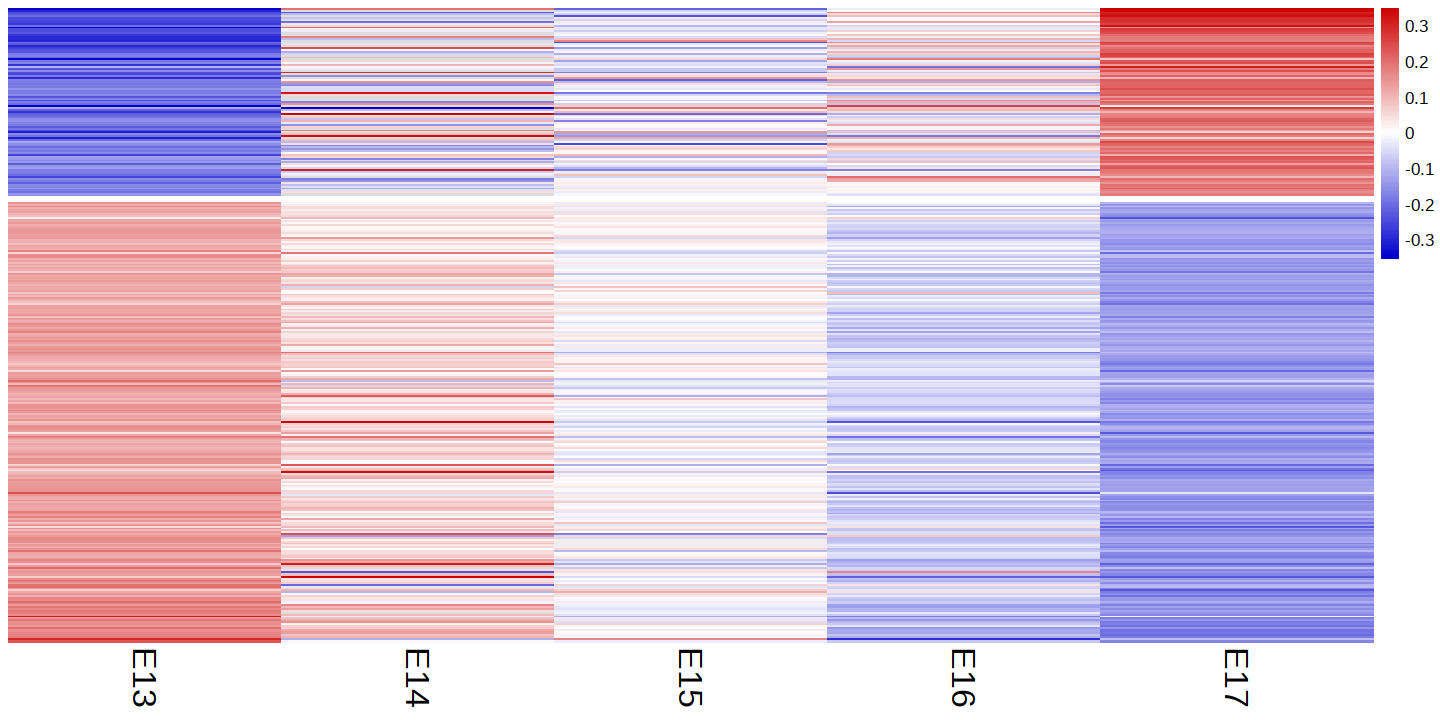

In [235]:
p_tad_borders_all <- pheatmap::pheatmap(pltmt - rowMeans(pltmt, na.rm = T), gaps_row = nrow(hvmm_inc),
                                        cluster_rows = F, cluster_cols = F, col = colorRampPalette(c('blue3', 'white', 'red3'))(100), show_rownames = F, fontsize_col =  20,
                   breaks = seq(-0.35,0.35,l=100))
mcATAC::save_pheatmap(p_tad_borders_all, './output/hic/figs/tad_borders_new.png', h = 800, w = 450)

png 
  2

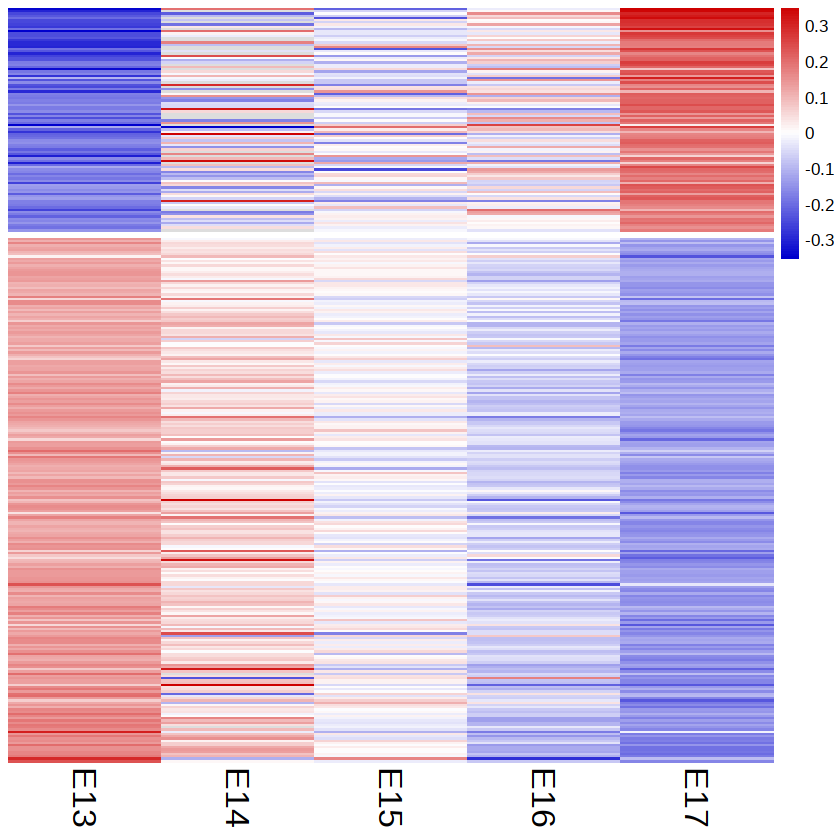

In [47]:
p_tad_borders_all <- pheatmap::pheatmap(pltmt - rowMeans(pltmt, na.rm = T), gaps_row = nrow(hvmm_inc),
                                        cluster_rows = F, cluster_cols = F, col = colorRampPalette(c('blue3', 'white', 'red3'))(100), show_rownames = F, fontsize_col =  20,
                   breaks = seq(-0.35,0.35,l=100))
save_pheatmap_pdf(p_tad_borders_all, './output/hic/figs/tad_borders_new.pdf', h = 800/100, w = 450/100)

In [48]:
e13_c <- grep('E13', colnames(mat_ipa), ign = T)
e17_c <- grep('E17', colnames(mat_ipa), ign = T)

In [49]:
ins_prc_uq10 <- gextract(ins_tracks, intervals = uq10_union_iter, iterator = uq10_union_iter)

In [50]:
ins_prc_uq10_can <- gintervals.canonic(ins_prc_uq10)

In [51]:
mat_ipu <- -1 * as.matrix(subset(ins_prc_uq10, select = -c(chrom, start, end, intervalID, mmcortex.tracks.E14_NSC.ins_250_dense)))

In [52]:
hi_var_minima_inds <- which(rowMaxs(mat_ipu) - rowMins(mat_ipu) >= quantile(rowMaxs(mat_ipu) - rowMins(mat_ipu), 0.95, na.rm = T))

In [53]:
pltmt <- mat_ipu[hi_var_minima_inds,]

In [54]:
colnames(pltmt) <- stringr::str_extract(colnames(pltmt), 'E\\d\\d')

In [55]:
hi_var_minima <- dplyr::mutate(ins_prc_uq10[hi_var_minima_inds,1:3], intervalID = hi_var_minima_inds)
hi_var_minima$chrom <- as.character(hi_var_minima$chrom)

In [245]:
# nsc_tads <- tibble::column_to_rownames(readr::read_tsv('~/raid/proj/mmcortex/output/mcatac/NSC_tads.tsv'), 'rowname')

# nsc_tads$tad_name <- rownames(nsc_tads)

In [246]:
# hvm_2d <- dplyr::bind_cols(hi_var_minima[,c('chrom', 'start', 'end')], hi_var_minima[,c('chrom', 'start', 'end', 'intervalID')])

In [56]:
hvm_2d <- dplyr::bind_cols(hvm, dplyr::mutate(hvm, intervalID = 1:nrow(hvm)))

New names:
* `chrom` -> `chrom...1`
* `start` -> `start...2`
* `end` -> `end...3`
* `chrom` -> `chrom...4`
* `start` -> `start...5`
* `end` -> `end...6`


In [57]:
colnames(hvm_2d) <- c('chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'intervalID')

In [47]:
dir.create('~/raid/proj/mmcortex/output/hic/figs/hi_var_minima')

Warning message in dir.create("~/raid/proj/mmcortex/output/hic/figs/hi_var_minima"):
"'/home/feshap/raid/proj/mmcortex/output/hic/figs/hi_var_minima' already exists"


In [58]:
m1 <- mat_ipu[hi_var_minima_inds,]

In [59]:
quantile(apply(m1[,c(1, ncol(m1))], 1, diff))

0%        25%        50%        75%       100% 
-0.5899365  0.2579889  0.3156867  0.3702927  0.9457035

In [60]:
hvm_sel <- gintervals.canonic(ins_prc_uq10[hi_var_minima_inds[which(abs(apply(m1[,c(1, ncol(m1))], 1, diff)) >= 0.25)],1:3])

In [61]:
quantile(apply(hvm_sel[,2:3],1, diff))

0%   25%   50%   75%  100% 
 5000  5000 10000 15000 35000

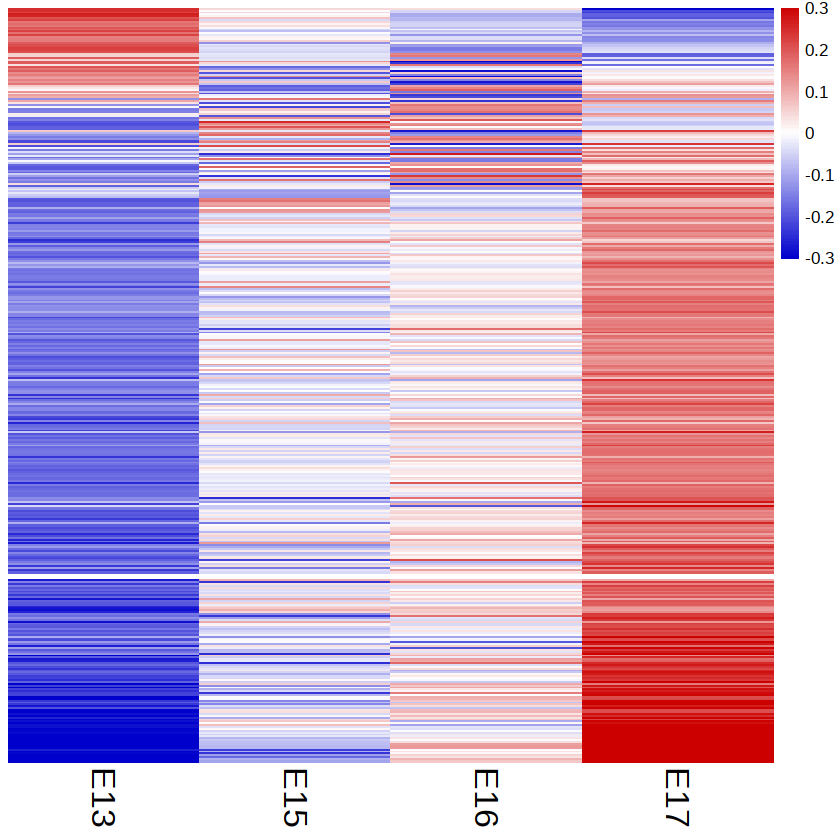

In [62]:
pltmt_sort <- pltmt - rowMeans(pltmt)
pltmt_sort <-pltmt_sort[order(pltmt_sort[,1] - pltmt_sort[,ncol(pltmt_sort)], decreasing = T),]
ppltmt <- pheatmap::pheatmap(pltmt_sort, gaps_row = length(which(pltmt_sort[,1] - pltmt_sort[,ncol(pltmt_sort)] <= -0.25)),
                             cluster_rows = F, col = colorRampPalette(c('blue3', 'white', 'red3'))(100), breaks = seq(-0.3,0.3,l=100), cluster_cols = F, show_rownames = F, treeheight_row = 0, fontsize_col = 20)

In [52]:
intis_inc <- head(rownames(hvmm_inc), 10)
intis_dec <- head(rownames(hvmm_dec), 10)
intis_inc
intis_dec

[1] "175" "75"  "214" "179" "330" "54"  "240" "188" "281" "81"

[1] "335" "130" "51"  "86"  "169" "118" "295" "242" "119" "38"

In [65]:
clrmp_trks <- colorRampPalette(c('yellow', 'blue'))(5)

## Fig 5C

In [157]:
dir.create('~/raid/proj/mmcortex/output/hic/figs/diff_ins_inc_new')
dir.create('~/raid/proj/mmcortex/output/hic/figs/diff_ins_dec_new')

In [243]:
options(repr.plot.height = 6)
options(repr.plot.width = 8)
# for (hvmi in intis_dec) {
for (hvmi in '86') {
    # hvmi <- hvmm_dec$intervalID == inti
    inti_nm <- paste0(hvmm_dec[hvmi,1:3], collapse = '_')
    print(inti_nm)
    tadi_fld <- glue::glue('~/raid/proj/mmcortex/output/hic/figs/diff_ins_dec_new/{inti_nm}')
    if (!dir.exists(tadi_fld)) {dir.create(tadi_fld)}
    SHIFT <- 50e+4
    gints1d_p <- dplyr::mutate(hvmm_dec[hvmi,], start = start -SHIFT, end = end + SHIFT)
    gints2d_p <- dplyr::mutate(hvm_2d[hvmi,], start1 = start1 -SHIFT, end1 = end1 + SHIFT,
                              start2 = start2 -SHIFT, end2 = end2 + SHIFT)

    nei_gints1d_ins_prc_all <- gintervals.neighbors(gints1d_p, ins_prc_all, mindist = 0, maxdist = 0, maxneighbors = 1e+7)
    inds <- nei_gints1d_ins_prc_all$intervalID
    # png(glue::glue('{tadi_fld}/ins_tracks.png'), h = 750, w = 1250)
    pdf(glue::glue('{tadi_fld}/ins_tracks.pdf'), h = 750/71, w = 1250/71)

    par(mar = c(7,10,1,1), cex.lab = 5, cex.main = 5, cex.axis = 5)
    yall <- -1 * ins_prc_all[inds,grep('E\\d\\d', colnames(ins_prc_all))]
    plot(ins_prc_all[inds,2], -1 * ins_prc_all[inds,grep('E13', colnames(ins_prc_all))], ylim = c(min(yall, na.rm = T), max(yall, na.rm = T)), bg = 'white',
         type = 'l', 
         lwd = 6,
         xaxt = 'n',
         col = clrmp_trks[[1]], pch = 16, cex = 1.5, 
         xlab = '',
         # xlab = unique(as.character(nei_gints1d_ins_prc_all$chrom)), 
         # main = paste0('Hi-var minima #', hvmi), 
         main = '',
         ylab = ''
         # ylab = 'Insulation'
         )
    # points(ins_prc_all[inds,2], mat_ipa_sm[inds,e13_c], pch = 1)
    lines(ins_prc_all[inds,2], -1*ins_prc_all[inds,grep('E14', colnames(ins_prc_all))], col = clrmp_trks[[2]], pch = 16, lwd = 6)
    lines(ins_prc_all[inds,2], -1*ins_prc_all[inds,grep('E15', colnames(ins_prc_all))], col = clrmp_trks[[3]], pch = 16, lwd = 6)
    lines(ins_prc_all[inds,2], -1*ins_prc_all[inds,grep('E16', colnames(ins_prc_all))], col = clrmp_trks[[4]], pch = 16, lwd = 6)
    lines(ins_prc_all[inds,2], -1*ins_prc_all[inds,grep('E17', colnames(ins_prc_all))], col = clrmp_trks[[5]], pch = 16, lwd = 6)
    title(xlab = unique(as.character(nei_gints1d_ins_prc_all$chrom)), line = 6)
    title(ylab = 'Insulation', line = 5)
    axis(1, padj = 0.5, hadj = -0.25)
    # points(ins_prc_all[inds,2], mat_ipa_sm[inds,e17_c], pch = 1)
    # lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e13_c], 0.15, na.rm = T), 2), col = 'red')
    # lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e17_c], 0.15, na.rm = T), 2), col = 'green')
    legend('topleft', cex = 4, col = clrmp_trks, legend = paste0('E', 13:17), lwd = 6)

    dev.off()
#     # ps13 = gextract(score_tracks[[trk13]], intervals = gints2d_p, colnames="score")
#     ps13 = gextract(score_tracks[[1]], intervals = gints2d_p, colnames="score")
#     ps14 = gextract(score_tracks[[2]], intervals = gints2d_p, colnames="score")
#     # ps15 = gextract(score_tracks[[trk15]], intervals = gints2d_p, colnames="score")
#     ps16 = gextract(score_tracks[[3]], intervals = gints2d_p, colnames="score")
#     ps17 = gextract(score_tracks[[4]], intervals = gints2d_p, colnames="score")
#     # ps17 = gextract(score_tracks[[trk17]], intervals = gints2d_p, colnames="score")


#     # png(glue::glue('{tadi_fld}/hic_score_E13.png'), h = 300, w = 500)
#     # shaman_plot_map_score_with_annotations2(genome = 'mm10',add_genes = F, points_score = ps13, interval_range = gints1d_p, add_ideogram = F)
#     # dev.off()
    
#     # png(glue::glue('{tadi_fld}/hic_score_E13.png'), h = 800, w = 1000)
#     pdf(glue::glue('{tadi_fld}/hic_score_E13.pdf'), h = 800/71, w = 1000/71)
#     shaman_plot_map_score_with_annotations(genome = 'mm10',add_genes = F, points_score = ps13, point_size = 2, interval_range = gints1d_p, add_ideogram = F)
#     dev.off()
#     # png(glue::glue('{tadi_fld}/hic_score_E14.png'), h = 800, w = 1000)
#     pdf(glue::glue('{tadi_fld}/hic_score_E14.pdf'), h = 800/71, w = 1000/71)
#     shaman_plot_map_score_with_annotations(genome = 'mm10',add_genes = F, points_score = ps14, point_size = 2, interval_range = gints1d_p, add_ideogram = F)
#     dev.off()
#     # png(glue::glue('{tadi_fld}/hic_score_E16.png'), h = 800, w = 1000)
#     pdf(glue::glue('{tadi_fld}/hic_score_E16.pdf'), h = 800/71, w = 1000/71)
#     shaman_plot_map_score_with_annotations(genome = 'mm10',add_genes = F, points_score = ps16, point_size = 2, interval_range = gints1d_p, add_ideogram = F)
#     dev.off()
#     # png(glue::glue('{tadi_fld}/hic_score_E17.png'), h = 800, w = 1000)
#     pdf(glue::glue('{tadi_fld}/hic_score_E17.pdf'), h = 800/71, w = 1000/71)
#     shaman_plot_map_score_with_annotations(genome = 'mm10',add_genes = T, points_score = ps17, point_size = 2, interval_range = gints1d_p, add_ideogram = F)
#     dev.off()
}

[1] "chr13_89543000_89618000"


Chosen intervals to plot:  
Hapln1 - diff_ins_dec_new/chr13_89543000_89618000  
Meis2 - diff_ins_inc_new/chr2_116080000_116192000  
Tnc - diff_ins_inc_new/chr4_63924000_64028000

In [40]:
pltmtf <- pltmt[,grep('E14', colnames(mat_ipu), inv=T)]

In [150]:
options(repr.plot.height = 10)
    options(repr.plot.width = 6)

In [145]:
options(repr.plot.height = 6)
    options(repr.plot.width = 6)

In [147]:
length(which(pltmt_sort[,1] - pltmt_sort[,ncol(pltmt_sort)] >= 0.4))

[1] 56

In [123]:
nrow(hvm_sel)

[1] 25

In [124]:
length(hi_var_minima_inds)

[1] 391

In [204]:
pltmtf_sort <- pltmtf - rowMeans(pltmtf)
ppltmtf <-pheatmap::pheatmap(pltmtf_sort[order(pltmtf_sort[,1] - pltmtf_sort[,ncol(pltmtf_sort)], decreasing = T),], cluster_rows = F, gaps_row = length(which(pltmt_sort[,1] - pltmt_sort[,ncol(pltmt_sort)] >= 0.4)),
                             col = colorRampPalette(c('blue3', 'white', 'red3'))(100), breaks = seq(-0.3,0.3,l=100), cluster_cols = F, show_rownames = F, treeheight_row = 0, fontsize_col = 20)

pltmtf_sort <- pltmtf - rowMeans(pltmtf)
ppltmtf <-pheatmap::pheatmap(pltmtf_sort[order(pltmtf_sort[,1] - pltmtf_sort[,ncol(pltmtf_sort)], decreasing = T),], cluster_rows = F, gaps_row = length(which(pltmt_sort[,1] - pltmt_sort[,ncol(pltmt_sort)] >= 0.4)),
                             col = colorRampPalette(c('blue3', 'white', 'red3'))(100), breaks = seq(-0.3,0.3,l=100), cluster_cols = F, show_rownames = F, treeheight_row = 0, fontsize_col = 20)

In [206]:
mcATAC::save_pheatmap(ppltmt, './output/hic/figs/ins_5k_bins_rel.png', h = 900, w = 500)
mcATAC::save_pheatmap(ppltmtf, './output/hic/figs/ins_5k_bins_rel_filt_e14.png', h = 900, w = 500)

png 
  2

png 
  2

## TAD border accessibility

In [127]:
nei_hvm_all_peaks <- gintervals.neighbors(dplyr::mutate(hvm_sel, intervalID = 1:nrow(hvm_sel)), dplyr::select(mcp, chrom, start, end, peak_name), mindist = 0, maxdist = 1e+6, maxneighbors = 1e+6)
nei_ins_all_peaks <- gintervals.neighbors(dplyr::mutate(ins_prc_uq10_can, intervalID = 1:nrow(ins_prc_uq10_can)), dplyr::select(mcp, chrom, start, end, peak_name), mindist = 0, maxdist = 1e+6, maxneighbors = 1e+6)

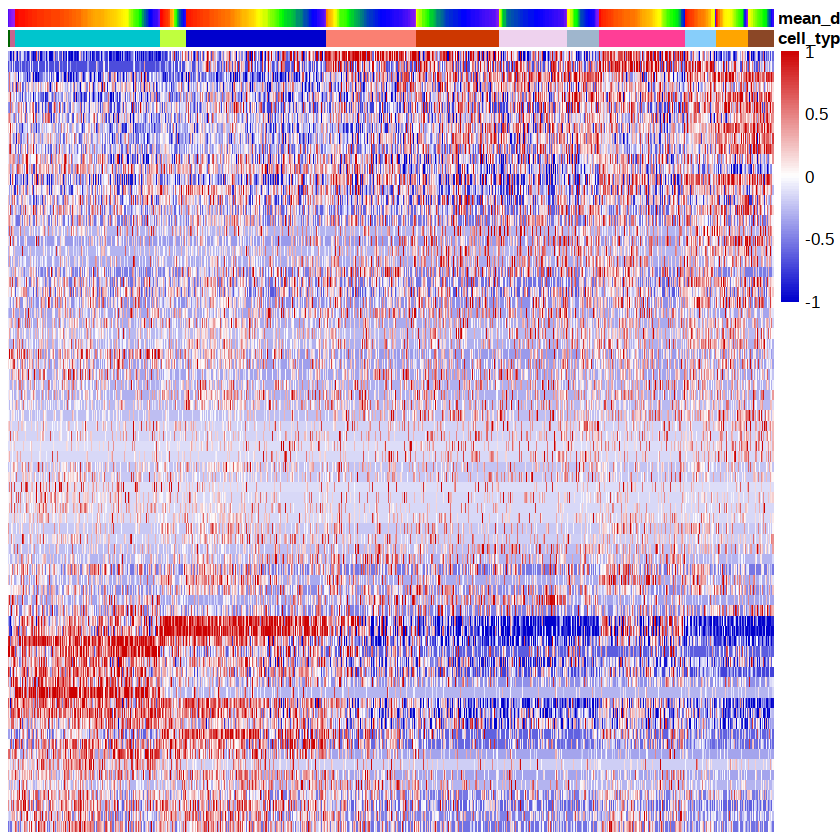

In [262]:
pltmt <- a_legc[unique(nei_hvm_all_peaks$peak_name[nei_hvm_all_peaks$dist <= 5e+4]),cust_mc_ord_st]
ppltmtf1 <-pheatmap::pheatmap(pltmt - rowMeans(pltmt), cluster_rows = T, annotation_col = col_annot, annotation_colors = ann_colors, annotation_legend = F,
                             show_colnames = F, clustering_method = 'ward.D2',
                             col = colorRampPalette(c('blue3', 'white', 'red3'))(100), breaks = seq(-1,1,l=100),
                             cluster_cols = F, show_rownames = F, treeheight_row = 0, fontsize_col = 20)

In [81]:
pltmt <- a_legc[unique(nei_ins_all_peaks$peak_name[nei_ins_all_peaks$dist <= 5e+4]),cust_mc_ord_st]
km_pltmt <- tglkmeans::TGL_kmeans(pltmt, seed = 1337, k = 16)

Warning message in TGL_kmeans_tidy(df = df, k = k, metric = metric, max_iter = max_iter, :
"Input doesn't have a column named "id". Using rownames instead."


In [82]:
options(repr.plot.height = 18)
    options(repr.plot.width = 12)

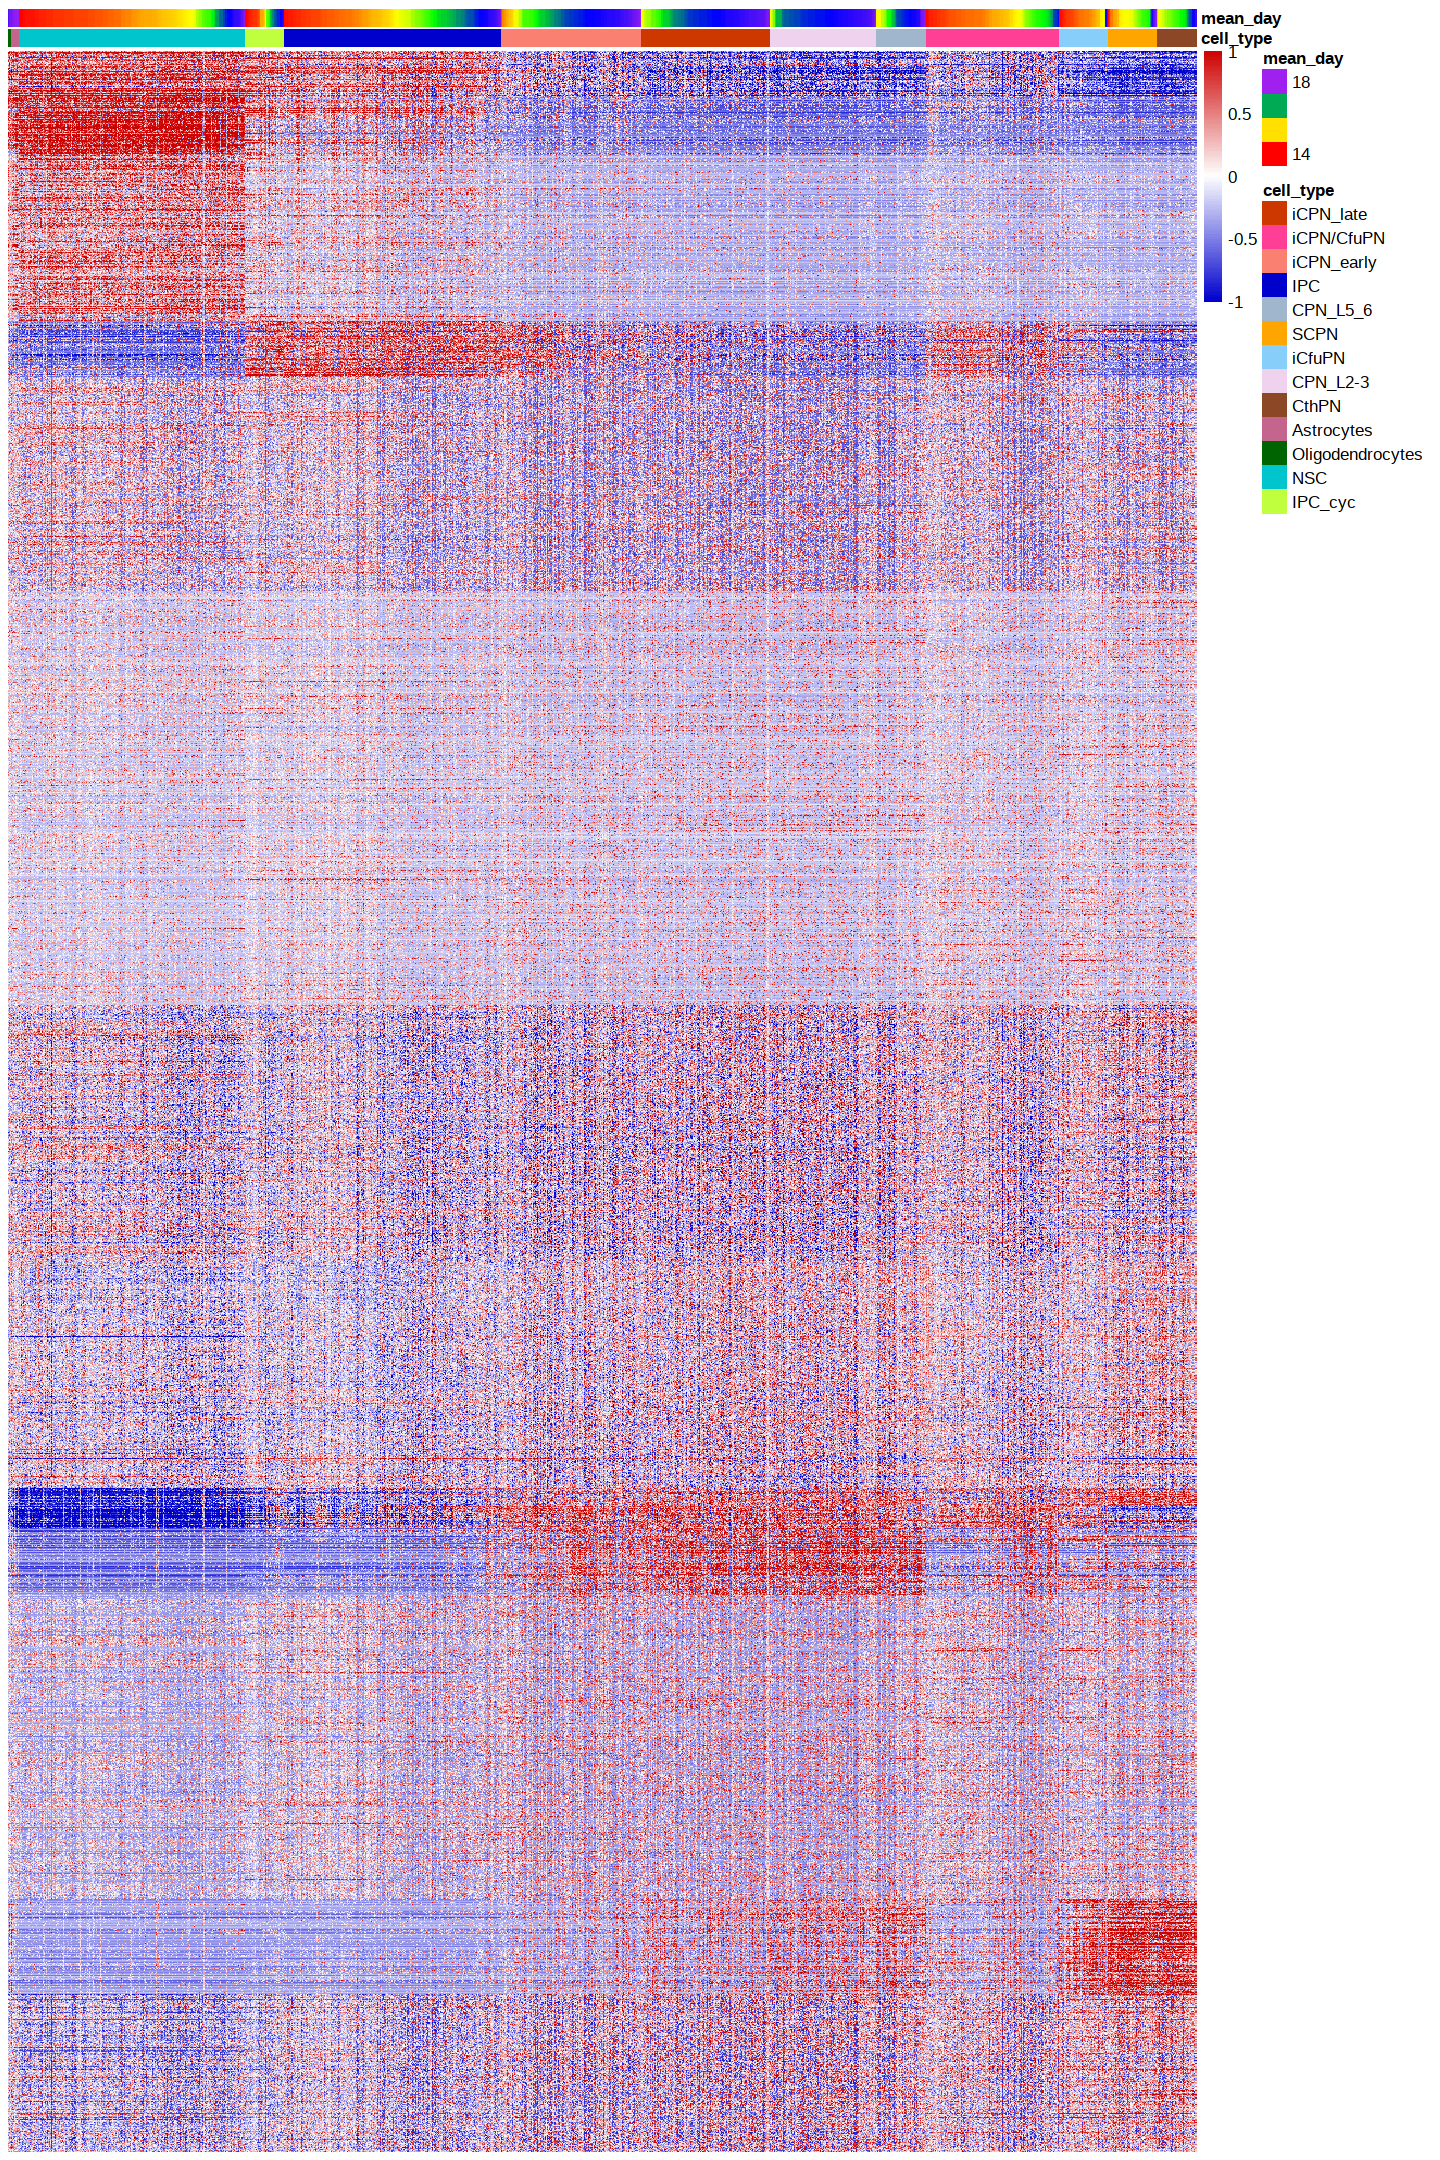

In [83]:
ppltmtf <-pheatmap::pheatmap(pltmt[order(km_pltmt$cluster),] - rowMeans(pltmt[order(km_pltmt$cluster),]), cluster_rows = F, annotation_col = col_annot, annotation_colors = ann_colors, 
                             show_colnames = F, clustering_method = 'ward.D2',
                             col = colorRampPalette(c('blue3', 'white', 'red3'))(100), breaks = seq(-1,1,l=100),
                             cluster_cols = F, show_rownames = F, treeheight_row = 0, fontsize_col = 20)

In [87]:
mcATAC::save_pheatmap(ppltmtf1, './output/hic/figs/hvm_peaks_nei_100k.png', h = 900, w = 800)

png 
  2

In [85]:
mcATAC::save_pheatmap(ppltmtf, './output/hic/figs/ins_all_peaks_nei_100.png', h = 3900, w = 2000)

png 
  2

png 
  2

In [ ]:
ls()

In [ ]:
## Check association with:
# NSC asc./desc. peaks
# Astro. peaks
# NSC genes
# Astro genes

In [42]:
# options(repr.plot.height = 8)
#     options(repr.plot.width = 8)

# ins_shift_hot_spots_1 <- ins_prc_all[which(mat_ipa_sm[,e13_c] - mat_ipa_sm[,e17_c] >= quantile(mat_ipa_sm[,e13_c] - mat_ipa_sm[,e17_c], 0.999, na.rm = T)),1:3]
# ins_shift_hot_spots_2 <- ins_prc_all[which(mat_ipa_sm[,e17_c] - mat_ipa_sm[,e13_c] >= quantile(mat_ipa_sm[,e17_c] - mat_ipa_sm[,e13_c], 0.999, na.rm = T)),1:3]
# ins_shift_hot_spots <- gintervals.canonic(gintervals.union(ins_shift_hot_spots_1, ins_shift_hot_spots_2))

# inds_na <- which(na_per_interv <= 2)

# vqi <- mat_ipa_q[,e13_c] - mat_ipa_q[,e17_c]

# getwd()

# setwd("/net/mraid14/export/tgdata/users/yonshap/proj/mmcortex/")

#     options(repr.plot.height = 6)
#     options(repr.plot.width = 12)

# # png('./output/hic/figs/calling_tad_borders_example.png', h = 500, w = 1100)
# mari <- c(5,5,3,1)
# par(mfrow = c(1,2), mar = mari, cex.lab = 2, cex.main = 1.5)
# inds <- 4e+3:5e+3
# plot(ins_prc_all[inds,2], mat_ipa[inds,e13_c], col = 'yellow', pch = 16, main = paste0('Raw insulation tracks, iterator = 1kbp'), xlab = 'chr1', ylab = 'Insulation')
# # points(ins_prc_all[inds,2], mat_ipa[inds,e13_c], pch = 1)
# points(ins_prc_all[inds,2], mat_ipa[inds,e17_c], col = 'blue', pch = 16)
# # points(ins_prc_all[inds,2], mat_ipa[inds,e17_c], pch = 1)
# lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e13_c], 0.15, na.rm = T), 2), col = 'red')
# lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e17_c], 0.15, na.rm = T), 2), col = 'green')
# legend('bottomleft', pch = c(16,16,NA,NA), col = c('yellow', 'blue', 'red', 'green'), lwd = c(NA, NA, 1,1), legend = c('E13', 'E17', 'E13 q = 0.1', 'E17 q = 0.1'))
# # title(xlab = 'chr1', ylab = 'Insulation')
# # plot(ins_prc_all[inds,2], mat_ipa_q[inds,e13_c], col = 'yellow', pch = 16)
# # points(ins_prc_all[inds,2], mat_ipa_q[inds,e13_c], pch = 1)
# # points(ins_prc_all[inds,2], mat_ipa_q[inds,e17_c], col = 'blue', pch = 16)
# # points(ins_prc_all[inds,2], mat_ipa_q[inds,e17_c], pch = 1)
# # lines(ins_prc_all[c(min(inds), max(inds)),2], rep(0.15, , 2), col = 'green')
# mari[[2]] <- 2
# par(mar = mari)
# plot(ins_prc_all[inds,2], mat_ipa_sm[inds,e13_c], col = 'yellow', pch = 16, main = paste0('Smoothed insulation tracks, k_sm = 5'), xlab = 'chr1', ylab = '')
# # points(ins_prc_all[inds,2], mat_ipa_sm[inds,e13_c], pch = 1)
# points(ins_prc_all[inds,2], mat_ipa_sm[inds,e17_c], col = 'blue', pch = 16)
# # points(ins_prc_all[inds,2], mat_ipa_sm[inds,e17_c], pch = 1)
# lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e13_c], 0.15, na.rm = T), 2), col = 'red')
# lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e17_c], 0.15, na.rm = T), 2), col = 'green')
# legend('bottomleft', pch = c(16,16,NA,NA), col = c('yellow', 'blue', 'red', 'green'), lwd = c(NA, NA, 1,1), legend = c('E13', 'E17', 'E13 q = 0.1', 'E17 q = 0.1'))
# # dev.off()

In [43]:
# EPS <- 0.01

# Q <- 0.15

# e13_q90 <- which(mat_ipa_sm[,e13_c] >= quantile(mat_ipa_sm[,e13_c], Q, na.rm = T) - EPS & mat_ipa_sm[,e13_c] <= quantile(mat_ipa_sm[,e13_c], Q, na.rm = T) + EPS)

# e17_q90 <- which(mat_ipa_sm[,e17_c] >= quantile(mat_ipa_sm[,e17_c], Q, na.rm = T) - EPS & mat_ipa_sm[,e17_c] <= quantile(mat_ipa_sm[,e17_c], Q, na.rm = T) + EPS)


# e13_q90_unif <- which(diff(e13_q90) > 10)
# head(e13_q90, 50)
# head(e13_q90[e13_q90_unif], 50)

# e17_q90_unif <- which(diff(e17_q90) > 10)
# head(e17_q90, 50)
# head(e17_q90[e17_q90_unif], 50)


# e13_q90_coords <- ins_prc_all[e13_q90[e13_q90_unif],1:3]
# e17_q90_coords <- ins_prc_all[e17_q90[e17_q90_unif],1:3]

# MAX_DIST <- 5e+6

# nei_e13_e17 <- gintervals.neighbors(dplyr::mutate(e13_q90_coords, strand = 1, ind = e13_q90[e13_q90_unif]), dplyr::mutate(e17_q90_coords, ind = e17_q90[e17_q90_unif], strand = 1), mindist = -MAX_DIST, maxdist = MAX_DIST, maxneighbors = 1)

# nei_e13_e17$nei_id <- 1:nrow(nei_e13_e17)

In [79]:
head(hvm)

,chrom,start,end
,<fct>,<dbl>,<dbl>
1,chr1,4392000,4422000
2,chr1,7087000,7121000
3,chr1,24305000,24329000
4,chr1,34824000,34830000
5,chr1,34831000,34858000
6,chr1,41891000,41915000


In [80]:
nrow(hvm)

[1] 551

### TAD border calling example

In [93]:
options(repr.plot.height = 8)
    options(repr.plot.width = 12)


In [641]:
hvm_ord <- hvm[order(hvm_mean[,1] - hvm_mean[,ncol(hvm_mean)], decreasing = F),]

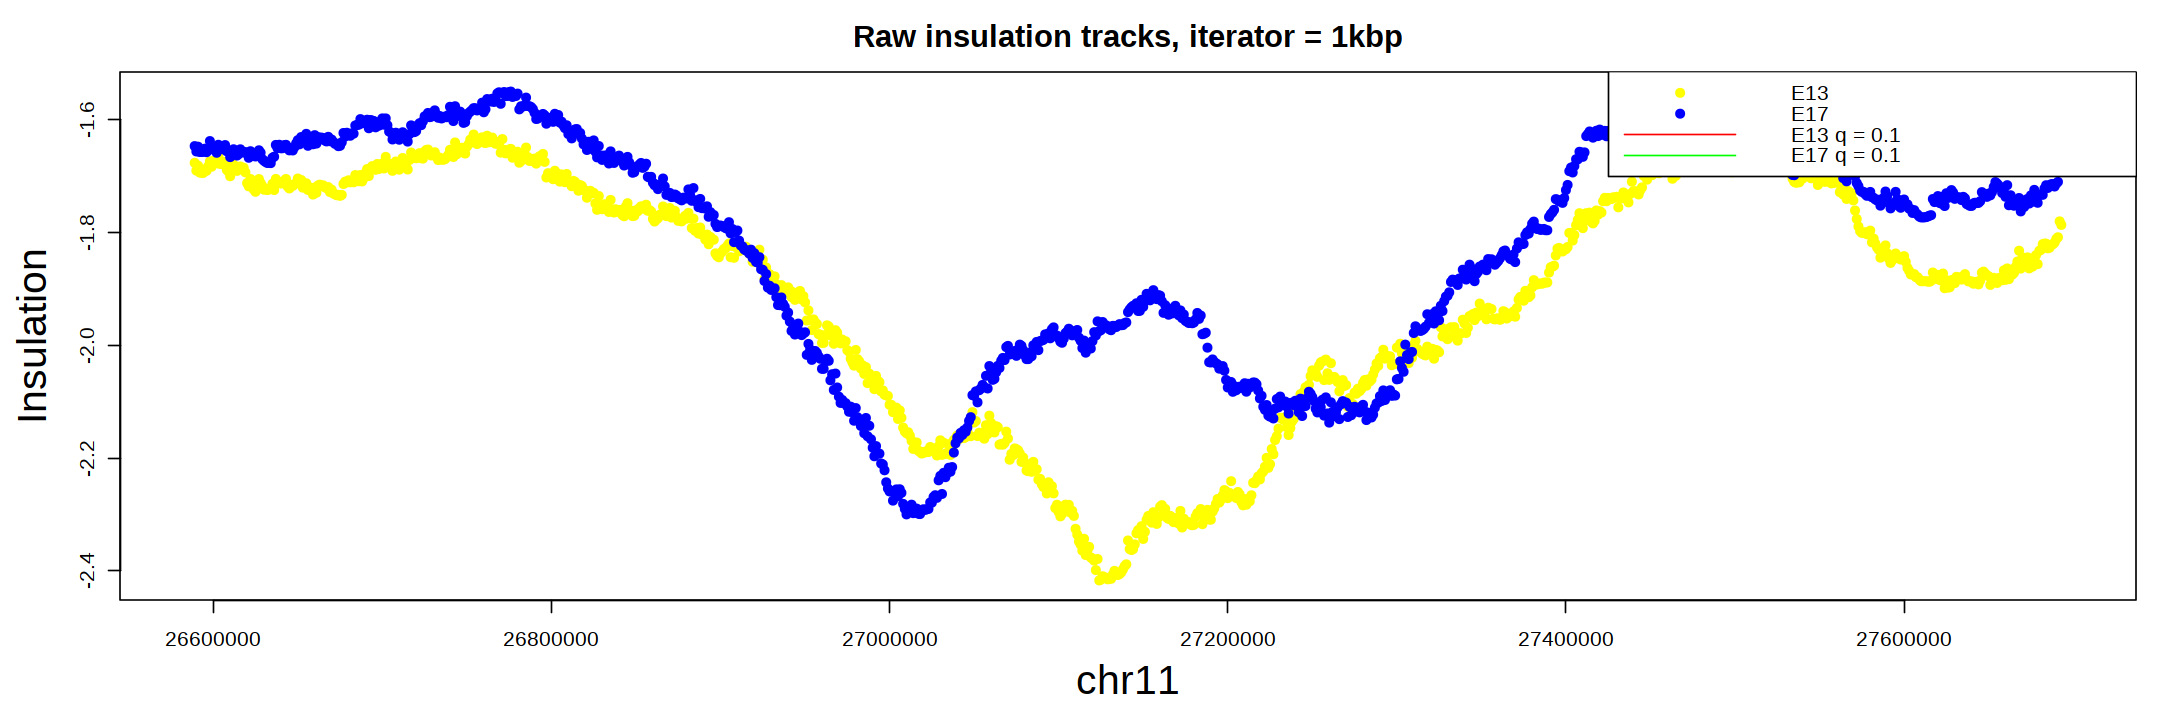

In [644]:
SHIFT <- 50e+4# png('./output/hic/figs/calling_tad_borders_example.png', h = 500, w = 1100)
mari <- c(5,5,3,1)
par(mar = mari, cex.lab = 2, cex.main = 1.5)
hvm_ind <- 3
nei_hvm_ins_prc_all <- gintervals.neighbors(dplyr::mutate(hvm_ord[hvm_ind,], start = start - SHIFT, end = end + SHIFT), ins_prc_all, mindist = 0, maxdist = 1, maxneighbors = 1e+6)

# inds <- nei_hvm_ins_prc_all$intervalID[nei_hvm_ins_prc_all$intervalID %in% e13_e17_nna]

# intervs_in <- dplyr::mutate(ins_prc_all[inds,1:3], start = start - SHIFT, end = end + SHIFT)
chr_in <- hvm_ord[hvm_ind,'chrom']

y1 <- nei_hvm_ins_prc_all[,'mmcortex.tracks.E13_NSC.ins_250_dense']
y2 <- nei_hvm_ins_prc_all[,'mmcortex.tracks.E17_NSC.ins_250_dense']
ylimi <- c(min(c(y1, y2), na.rm = T), max(c(y1, y2), na.rm = T))

plot(nei_hvm_ins_prc_all[,5], y1, col = 'yellow', pch = 16, main = paste0('Raw insulation tracks, iterator = 1kbp'), xlab = chr_in, ylab = 'Insulation', ylim = ylimi)
# points(ins_prc_all[inds,2], mat_ipa[inds,e13_c], pch = 1)
points(nei_hvm_ins_prc_all[,5], y2, col = 'blue', pch = 16)
# points(ins_prc_all[inds,2], mat_ipa[inds,e17_c], pch = 1)
# lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e13_c], 0.15, na.rm = T), 2), col = 'red')
# lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e17_c], 0.15, na.rm = T), 2), col = 'green')
legend('topright', pch = c(16,16,NA,NA), col = c('yellow', 'blue', 'red', 'green'), lwd = c(NA, NA, 1,1), legend = c('E13', 'E17', 'E13 q = 0.1', 'E17 q = 0.1'))
# title(xlab = 'chr1', ylab = 'Insulation')
# plot(ins_prc_all[inds,2], mat_ipa_q[inds,e13_c], col = 'yellow', pch = 16)
# points(ins_prc_all[inds,2], mat_ipa_q[inds,e13_c], pch = 1)
# points(ins_prc_all[inds,2], mat_ipa_q[inds,e17_c], col = 'blue', pch = 16)
# points(ins_prc_all[inds,2], mat_ipa_q[inds,e17_c], pch = 1)
# lines(ins_prc_all[c(min(inds), max(inds)),2], rep(0.15, , 2), col = 'green')
# mari[[2]] <- 2
# par(mar = mari)

# plot(ins_prc_all[inds,2], mat_ipa[inds,e13_c], col = 'yellow', pch = 16, main = paste0('Smoothed insulation tracks, k_sm = 5'), xlab = chr_in, ylab = 'Insulation score')
# # points(ins_prc_all[inds,2], mat_ipa_sm[inds,e13_c], pch = 1)
# points(ins_prc_all[inds,2], mat_ipa[inds,e17_c], col = 'blue', pch = 16)

# # points(nei_e13_e17[nei_e13_e17$chrom == chr_in,2], mat_ipa[nei_e13_e17[nei_e13_e17$chrom == chr_in,5],e13_c], col = 'red', pch = 1, cex = 6, lwd = 2)
# # points(nei_e13_e17[nei_e13_e17$chrom == chr_in,7], mat_ipa[nei_e13_e17[nei_e13_e17$chrom == chr_in,9],e17_c], col = 'green', pch = 1, cex = 6, lwd = 2)

# # points(ins_prc_all[inds,2], mat_ipa_sm[inds,e17_c], pch = 1)
# lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e13_c], 0.15, na.rm = T), 2), col = 'red')
# lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e17_c], 0.15, na.rm = T), 2), col = 'green')
# legend('bottomleft',
#        pch = c(16,16,NA,NA, 1,1),
#        # cex = c(1,1,NA, NA,1,1), 
#        col = c('yellow', 'blue', 'red', 'green', 'red', 'green'), 
#        lwd = c(NA, NA, 1,1, NA, NA), 
#        legend = c('E13', 'E17', 'E13 q = 0.1', 'E17 q = 0.1', 
#                   'E13 border call', 'E17 border call')
#       )
# dev.off()

### TAD border with high shift example

In [193]:
    options(repr.plot.height = 8)
    options(repr.plot.width = 8)

In [132]:
nei_hotspot_bord_shift <- gintervals.neighbors(ins_shift_hot_spots, nei_e13_e17[abs(nei_e13_e17$dist) >= 1e+5,], mindist = -3e+5, maxdist = 3e+5)

In [133]:
nei_hotspot_bord_shift

,chrom,start,end,chrom,start,end,strand,ind,chrom,start,end,ind,strand,dist,nei_id,dist
,<fct>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<int>,<fct>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>
1,chr1,85592000,85595000,chr1,85503000,85504000,1,85504,chr1,85850000,85851000,85851,1,-346000,192,88000
2,chr1,118212000,118258000,chr1,118334000,118335000,1,118335,chr1,118051000,118052000,118052,1,282000,262,-76000
3,chr11,27099000,27189000,chr11,27237000,27238000,1,353405,chr11,27046000,27047000,353214,1,190000,890,-48000
4,chr12,17841000,17971000,chr12,18174000,18175000,1,466425,chr12,17762000,17763000,466013,1,411000,1239,-203000
5,chr12,17977000,17978000,chr12,18174000,18175000,1,466425,chr12,17762000,17763000,466013,1,411000,1239,-196000
6,chr12,17979000,17980000,chr12,18174000,18175000,1,466425,chr12,17762000,17763000,466013,1,411000,1239,-194000
7,chr12,17983000,17988000,chr12,18174000,18175000,1,466425,chr12,17762000,17763000,466013,1,411000,1239,-186000
8,chr13,3359000,3374000,chr13,3310000,3311000,1,571691,chr13,3482000,3483000,571863,1,-171000,1466,48000
9,chr13,21733000,21738000,chr13,21859000,21860000,1,590240,chr13,21640000,21641000,590021,1,218000,1514,-121000


In [147]:

mari <- c(5,5,3,1)
inds <- 832e+3:833e+3
intervs_in <- gintervals.neighbors(ins_prc_all[inds,], nei_e13_e17, maxneighbors = 1)
chr_in <- unique(as.character(nei_e13_e17$chrom[unique(intervs_in$nei_id)]))

# mari[[2]] <- 2
interv_nm <- paste0(c(unique(as.character(intervs_in[,1])), min(intervs_in[,2]), max(intervs_in[,3])), collapse = '_')
png(glue::glue('./output/hic/figs/{interv_nm}.png'), h = 600, w = 600)
par(mar = mari, cex.lab = 2, cex.main = 1.5, cex.axis = 2)
# par(mar = mari)

plot(ins_prc_all[inds,2], mat_ipa_sm[inds,e13_c], col = 'yellow', pch = 16, main = interv_nm, xlab = chr_in, ylab = 'Insulation score')
# points(ins_prc_all[inds,2], mat_ipa_sm[inds,e13_c], pch = 1)
points(ins_prc_all[inds,2], mat_ipa_sm[inds,e17_c], col = 'blue', pch = 16)

points(nei_e13_e17[nei_e13_e17$chrom == chr_in,2], mat_ipa_sm[nei_e13_e17[nei_e13_e17$chrom == chr_in,5],e13_c], col = 'red', pch = 1, cex = 6, lwd = 2)
points(nei_e13_e17[nei_e13_e17$chrom == chr_in,7], mat_ipa_sm[nei_e13_e17[nei_e13_e17$chrom == chr_in,9],e17_c], col = 'green', pch = 1, cex = 6, lwd = 2)

# points(ins_prc_all[inds,2], mat_ipa_sm[inds,e17_c], pch = 1)
lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e13_c], 0.15, na.rm = T), 2), col = 'red')
lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e17_c], 0.15, na.rm = T), 2), col = 'green')
# legend('bottomleft',
#        pch = c(16,16,NA,NA, 1,1),
#        # cex = c(1,1,NA, NA,1,1), 
#        col = c('yellow', 'blue', 'red', 'green', 'red', 'green'), 
#        lwd = c(NA, NA, 1,1, NA, NA), 
#        legend = c('E13', 'E17', 'E13 q = 0.1', 'E17 q = 0.1', 
#                   'E13 border call', 'E17 border call')
#       )
dev.off()

png 
  2

In [97]:
dir.create('./output/hic/figs/ins_shift_hotspots/')

In [102]:
# png('./output/hic/figs/calling_tad_borders_example.png', h = 500, w = 1100)
mari <- c(5,5,3,1)
SHIFT <- 5e+5
btbrt <- sapply(1:nrow(ins_shift_hot_spots), function(ind) {
    
    intervs <- ins_shift_hot_spots[ind,]
    intervs_in <- gintervals.neighbors(ins_prc_all, dplyr::mutate(intervs, start = start - SHIFT, end = end + SHIFT), maxneighbors = 1, mindist =0, maxdist = 0)
    chr_in <- intervs$chrom
    inds <- sort(unique(intervs_in$intervalID))
    mari[[2]] <- 2
    par(mar = mari)
    y_e13 <- mat_ipa_sm[inds,e13_c]
    y_e17 <- mat_ipa_sm[inds,e17_c]
    ylimi = c(min(c(y_e13, y_e17), na.rm = T), max(c(y_e13, y_e17), na.rm = T))
    png(glue::glue('./output/hic/figs/ins_shift_hotspots/{chr_in}_{intervs$start}_{intervs$end}.png'))
    par(mar = mari, cex.lab = 2, cex.main = 1.5)
    plot(ins_prc_all[inds,2], y_e13, ylim = ylimi, col = 'yellow', 
         pch = 16, main = paste0(dplyr::mutate(intervs, chrom = as.character(chrom), start = start - SHIFT, end = end + SHIFT), collapse = '_'),
         xlab = chr_in, ylab = 'Insulation score')
    # points(ins_prc_all[inds,2], mat_ipa_sm[inds,e13_c], pch = 1)
    points(ins_prc_all[inds,2], y_e17, col = 'blue', pch = 16)

    points(nei_e13_e17[nei_e13_e17$chrom == chr_in,2], mat_ipa_sm[nei_e13_e17[nei_e13_e17$chrom == chr_in,5],e13_c], col = 'red', pch = 1, cex = 6, lwd = 2)
    points(nei_e13_e17[nei_e13_e17$chrom == chr_in,7], mat_ipa_sm[nei_e13_e17[nei_e13_e17$chrom == chr_in,9],e17_c], col = 'green', pch = 1, cex = 6, lwd = 2)

    # points(ins_prc_all[inds,2], mat_ipa_sm[inds,e17_c], pch = 1)
    lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e13_c], 0.15, na.rm = T), 2), col = 'red')
    lines(ins_prc_all[c(min(inds), max(inds)),2], rep(quantile(mat_ipa[,e17_c], 0.15, na.rm = T), 2), col = 'green')
    lines(rep(intervs$start, 2), c(-10,0), lwd = 2, col= 'orange', lty = 2)
    dev.off()
})
# ind <- 26

# legend('bottomleft',
#        pch = c(16,16,NA,NA, 1,1),
#        # cex = c(1,1,NA, NA,1,1), 
#        col = c('yellow', 'blue', 'red', 'green', 'red', 'green'), 
#        lwd = c(NA, NA, 1,1, NA, NA), 
#        legend = c('E13', 'E17', 'E13 q = 0.1', 'E17 q = 0.1', 
#                   'E13 border call', 'E17 border call')
#       )
# dev.off()

In [115]:
png('./output/hic/figs/distance_between_e13_e17_tad_border_calls_ecdf.png', h = 600, w = 600)
par(las = 2, cex.axis = 2, mar = c(10,6,5,1), cex.main = 2, cex.lab = 2)
plot(ecdf(log2(abs(ifelse(nei_e13_e17$dist == 0, 1, nei_e13_e17$dist)))),  lwd = 2,
     ylab = '', xlim = c(10,21), do.points = F, 
     xlab = '', main = 'Absolute distance between closest\nTAD borders E13 vs E17', 
     xaxt = 'n', col = 'orange1')
title(xlab = 'Distance [bp]', line = 8)
title(ylab = 'Fn(x)', line = 4)
axis(1, at = seq(5,25,1), labels = round(2**seq(5,25,1), -3))
grid(col = 'lightgray', lwd = 2, lty = 2)
dev.off()

png 
  2

## E-P contact analysis

In [171]:
library(tgstat)

In [172]:
get_genes_specific_to_mcs <- function(legc, mc_pos = NULL, mc_neg = NULL, cl_vec = NULL) {
    if (!is.null(mc_pos) && is.null(mc_neg)) {
        cl_vec <- ifelse(1:ncol(legc) %in% mc_pos, 1, 0)
    } else if (!is.null(mc_pos) && !is.null(mc_neg)) {
        if (!(length(intersect(mc_pos, mc_neg)) == 0)) {
            stop('mc_pos and mc_neg intersect')
        }
        legc <- legc[,c(mc_pos, mc_neg)]
        cl_vec <- c(rep(1, length(mc_pos)), rep(0, length(mc_neg)))
    }
    legc_avg <- t(tgs_matrix_tapply(legc, cl_vec, mean))
    if (ncol(legc_avg) == 2) {
        diffs <- matrixStats::rowDiffs(legc_avg)
        rownames(diffs) <- rownames(legc_avg)
        return(diffs[order( diffs[,1], decreasing = T),])
    } else {
        diffs <- t(plyr::laply(1:ncol(legc_avg), function(i) legc_avg[,i] - matrixStats::rowMaxs(legc_avg[,-i]), .parallel = T))
        colnames(diffs) <- colnames(legc_avg)
        return(lapply(1:ncol(diffs), function(i) {
            df <- diffs[which(diffs[,i] > 0.1),]
            return(df[order(df[,i], decreasing = T),])
        }))
    }
}

In [173]:
neuro_cts <- c('SCPN', 'CthPN', 'CPN_L5_6', 'CPN_L2-3')
ipc_cts <- c('IPC', 'IPC_cyc')
m_genes = c("Mki67","Cenpf","Top2a","Smc4","Ube2c","Ccnb1","Cdk1","Arl6ip1","Ankrd11","Hmmr",
                "Cenpa","Tpx2","Aurka","Kif4", "Kif2c","Bub1b","Ccna2", "Kif23","Kif20a","Sgo2a",
                "Sgo2b","Smc2", "Kif11", "Cdca2","Incenp","Cenpe")
  s_genes = c("Pcna", "Rrm2", "Mcm5", "Mcm6", "Mcm4", "Ung", "Mcm7", "Mcm2","Uhrf1", "Orc6", "Tipin")
cc_genes <- union(m_genes, s_genes)

In [174]:
nsc_genes_vs_astro <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in% c('NSC')), mc_neg = which(mcmd$cell_type %in% c('Astrocytes')))
nsc_genes_vs_ipc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in% c('NSC')), mc_neg = which(mcmd$cell_type %in% c('IPC')))

In [175]:
# nsc_genes <- setdiff(intersect(names(nsc_genes_vs_astro)[nsc_genes_vs_astro >= 1], 
#                            names(nsc_genes_vs_ipc)[nsc_genes_vs_ipc >= 1]), cc_genes)

In [176]:
nsc_genes <- setdiff(union(names(nsc_genes_vs_astro)[nsc_genes_vs_astro >= 1], 
                           names(nsc_genes_vs_ipc)[nsc_genes_vs_ipc >= 1]), cc_genes)

In [177]:
length(nsc_genes)

[1] 940

In [178]:
ipc_genes <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in% c('IPC')))

In [179]:
ipc_genes_vs_neuro <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in% c('IPC', 'IPC_cyc')), mc_neg = which(mcmd$cell_type %in% c('CthPN', 'SCPN', 'CPN_L5_6', 'CPN_L2-3')))
ipc_genes_vs_nsc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in% c('IPC', 'IPC_cyc')), mc_neg = which(mcmd$cell_type %in% c('NSC')))

In [180]:
ipc_genes <- union(names(which(ipc_genes_vs_nsc >= 1)), names(which(ipc_genes_vs_neuro >= 1)))

In [181]:
ipc_genes <- setdiff(ipc_genes, union(cc_genes, nsc_genes))

In [182]:
# neuro_genes <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type %in% c('CthPN', 'SCPN', 'CPN_L5_6', 'CPN_L2-3')))
# neuro_genes <- setdiff(names(neuro_genes)[neuro_genes >= 1], union(cc_genes, ipc_genes))
neuro_genes <- names(ipc_genes_vs_neuro[ipc_genes_vs_neuro <= -1]) 

In [183]:
length(neuro_genes)

[1] 779

In [184]:
astro_genes_vs_oligo <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type == 'Astrocytes'), mc_neg = which(mcmd$cell_type %in% c('OPCs')))
astro_genes_vs_nsc <- get_genes_specific_to_mcs(legc, mc_pos = which(mcmd$cell_type == 'Astrocytes'), mc_neg = which(mcmd$cell_type %in% c('NSC')))
astro_genes <- union(names(astro_genes_vs_oligo[astro_genes_vs_oligo >= 1]), names(astro_genes_vs_nsc[astro_genes_vs_nsc >= 1]))
length(astro_genes)

[1] 1020

In [185]:
int_astro_neuro <- intersect(neuro_genes, astro_genes)

In [186]:
int_nsc_neuro <- intersect(neuro_genes, nsc_genes)

In [187]:
int_astro_ipc <- intersect(ipc_genes, astro_genes)

In [188]:
astro_genes <- setdiff(astro_genes, union(int_astro_ipc, int_astro_neuro))
neuro_genes <- setdiff(neuro_genes, union(int_nsc_neuro, int_astro_neuro))

int_astro_neuro <- intersect(neuro_genes, astro_genes)
int_nsc_neuro <- intersect(neuro_genes, nsc_genes)
int_astro_ipc <- intersect(ipc_genes, astro_genes)
length(int_astro_neuro)
length(int_nsc_neuro)
length(int_astro_ipc)

[1] 0

[1] 0

[1] 0

In [189]:
legc_avg_ct <- t(tgs_matrix_tapply(legc[,mcmd$metacell], mcmd$cell_type, mean))

In [121]:
# legc_avg_ct <- t(tgs_matrix_tapply(legc, mcmd$cell_type, mean))
# mc_fp_avg_ct <- t(tgs_matrix_tapply(mc_rna@mc_fp, mcmd$cell_type, mean))
# nsc_genes <- setdiff(rownames(mc_fp_avg_ct)[mc_fp_avg_ct[,'NSC'] >= 2], cc_genes)
# ipc_genes <- setdiff(rownames(mc_fp_avg_ct)[rowMaxs(mc_fp_avg_ct[,ipc_cts]) >= 2], cc_genes)
# neuro_genes <- setdiff(rownames(mc_fp_avg_ct)[rowMaxs(mc_fp_avg_ct[,neuro_cts]) >= 2], cc_genes)
# astro_genes <- setdiff(rownames(mc_fp_avg_ct)[mc_fp_avg_ct[,'Astrocytes'] >= 2], unique(c(cc_genes, nsc_genes, ipc_genes, neuro_genes)))
# int_nsc_ipc_genes <- intersect(nsc_genes, ipc_genes)
# nsc_genes <- setdiff(nsc_genes, int_nsc_ipc_genes)
# ipc_genes <- setdiff(ipc_genes, int_nsc_ipc_genes)
# int_genes_assign <- setNames(c('NSC', 'IPC_cyc')[apply(mc_fp_avg_ct[int_nsc_ipc_genes,c('NSC', 'IPC_cyc')], 1, which.max)], int_nsc_ipc_genes)
# int_genes_assign
# nsc_genes <- setdiff(union(nsc_genes, names(int_genes_assign[int_genes_assign == 'NSC'])), neuro_genes)
# ipc_genes <- setdiff(union(ipc_genes, names(int_genes_assign[int_genes_assign == 'IPC_cyc'])), neuro_genes)

In [190]:
ct_genes <- factor(setNames(c(
                       rep('nsc_gene', length(nsc_genes)),
                       rep('ipc_gene', length(ipc_genes)),
                       rep('neuro_gene', length(neuro_genes)),
                       rep('astro_gene', length(astro_genes))),
                     c(nsc_genes, ipc_genes, neuro_genes,astro_genes)),
                   levels = c('nsc_gene', 'ipc_gene', 'neuro_gene', 'astro_gene'))

In [191]:
prom_peaks <- gintervals.neighbors(mcp, tss2, mindist = -1e+3, maxdist = 1e+3, maxneighbors = 1)

dist_peaks <- mcp[!(mcp$peak_name %in% prom_peaks$peak_name),]

In [192]:
length(nsc_genes)

length(ipc_genes)
length(neuro_genes)
length(astro_genes)

[1] 940

[1] 854

[1] 585

[1] 745

In [193]:
## ct-specific genes
nsc_tss <- dplyr::mutate(tss2[tss2$geneSymbol %in% nsc_genes,c('chrom', 'start', 'end', 'geneSymbol')], type = 'nsc_tss') %>% filter(!duplicated(.$geneSymbol))

In [194]:
ipc_tss <- dplyr::mutate(tss2[tss2$geneSymbol %in% ipc_genes,c('chrom', 'start', 'end', 'geneSymbol')], type = 'ipc_tss') %>% filter(!duplicated(.$geneSymbol))
neuro_tss <- dplyr::mutate(tss2[tss2$geneSymbol %in% neuro_genes,c('chrom', 'start', 'end', 'geneSymbol')], type = 'neuro_tss') %>% filter(!duplicated(.$geneSymbol))

In [195]:
astro_tss <- dplyr::mutate(tss2[tss2$geneSymbol %in% astro_genes,c('chrom', 'start', 'end', 'geneSymbol')], type = 'astro_tss') %>% filter(!duplicated(.$geneSymbol))

In [196]:
# ct_tss_all <- rbind(nsc_tss, ipc_tss, neuro_tss, astro_tss)
# ct_peaks_all <- dplyr::mutate(rbind(nsc_peaks, ipc_peaks, neuro_peaks), start = start - SHIFT_DIAMOND, end = end + SHIFT_DIAMOND)

In [197]:
## ct-specific peaks

# load('./output/mcatac/mmcortex_feat_peak_variable_peak_clusters.rda')
load('./output/mcatac/var_peaks_after_enh_prom_separation.rda')

In [198]:
nsc_peaks_vs_astro <- get_genes_specific_to_mcs(a_legc, mc_pos = which(mcmd$cell_type %in% c('NSC')), mc_neg = which(mcmd$cell_type %in% c('Astrocytes')))
nsc_peaks_vs_ipc <- get_genes_specific_to_mcs(a_legc, mc_pos = which(mcmd$cell_type %in% c('NSC')), mc_neg = which(mcmd$cell_type %in% c('IPC')))

In [199]:
nsc_peaks <- union(names(nsc_peaks_vs_astro)[nsc_peaks_vs_astro >= 0.5], 
                           names(nsc_peaks_vs_ipc)[nsc_peaks_vs_ipc >= 0.5])

In [200]:
nsc_peaks_cor_day <- tgs_cor(t(a_legc[,nsc_mcs]), as.matrix(mcmd$mean_day[nsc_mcs]), spearman = T)

peaks_cor_day_nsc <- tgs_cor(t(egc_by_day_n), as.matrix(1:6), spearman = T)

l_egc_by_day_n <- log2(1e-5 + egc_by_day_n)

nsc_asc_peaks <- rownames(a_legc)[peaks_cor_day_nsc >= 0.5 & rowMaxs(l_egc_by_day_n)- rowMins(l_egc_by_day_n) >= 0.75]

nsc_desc_peaks <- rownames(a_legc)[-peaks_cor_day_nsc >= 0.5 & rowMaxs(l_egc_by_day_n)- rowMins(l_egc_by_day_n) >= 0.75]

In [201]:
ipc_peaks_vs_nsc <- get_genes_specific_to_mcs(a_legc, mc_pos = which(mcmd$cell_type == 'IPC'), mc_neg = which(mcmd$cell_type == 'NSC'))
ipc_peaks_vs_neuro <- get_genes_specific_to_mcs(a_legc, mc_pos = which(mcmd$cell_type == 'IPC'), mc_neg = which(mcmd$cell_type %in% c('CthPN', 'SCPN', 'CPN_L5_6', 'CPN_L2-3')))
ipc_peaks <- union(names(ipc_peaks_vs_nsc[ipc_peaks_vs_nsc >= 0.75]), names(ipc_peaks_vs_neuro[ipc_peaks_vs_neuro >= 0.75]))


neuro_peaks <- setdiff(names(ipc_peaks_vs_neuro[ipc_peaks_vs_neuro <= -0.75]), multunion(ipc_peaks, nsc_peaks))
# get_genes_specific_to_mcs(a_legc, mc_pos = which(mcmd$cell_type %in% c('CthPN', 'SCPN', 'CPN_L5_6', 'CPN_L2-3')))
# neuro_peaks <- setdiff(names(neuro_peaks)[neuro_peaks >= 0.5], ipc_peaks)

astro_peaks_vs_oligo <- get_genes_specific_to_mcs(a_legc, mc_pos = which(mcmd$cell_type == 'Astrocytes'), mc_neg = which(mcmd$cell_type %in% c('OPCs')))
astro_peaks_vs_nsc <- get_genes_specific_to_mcs(a_legc, mc_pos = which(mcmd$cell_type == 'Astrocytes'), mc_neg = which(mcmd$cell_type %in% c('NSC')))
astro_peaks <- union(names(astro_peaks_vs_nsc[astro_peaks_vs_nsc >= 0.75]), names(astro_peaks_vs_oligo[astro_peaks_vs_oligo >= 0.75]))


nsc_peaks <- setdiff(nsc_peaks, multunion(ipc_peaks, neuro_peaks, astro_peaks))
ipc_peaks <-  setdiff(ipc_peaks, multunion(nsc_peaks, neuro_peaks, astro_peaks))
astro_peaks <- setdiff(astro_peaks, multunion(ipc_peaks, nsc_peaks, neuro_peaks))
neuro_peaks <- setdiff(neuro_peaks, multunion(ipc_peaks, nsc_peaks, astro_peaks))

Length of arguments was 10421, 12475
Length of union is 21036
Length of arguments was 10421, 5887, 955
Length of union is 17099
Length of arguments was 10355, 5887, 955
Length of union is 17161
Length of arguments was 10293, 10355, 5887
Length of union is 26535
Length of arguments was 10293, 10355, 919
Length of union is 21567


In [202]:
# astro_peaks <- get_genes_specific_to_mcs(a_legc, mc_pos = which(mcmd$cell_type == 'Astrocytes'), mc_neg = which(mcmd$cell_type %in% c('NSC', 'IPC')))
# astro_peaks <- setdiff(names(astro_peaks)[astro_peaks >= 0.5], nsc_peaks)

In [203]:
length(nsc_peaks)
length(ipc_peaks)
length(neuro_peaks)
length(astro_peaks)

[1] 10355

[1] 10293

[1] 5887

[1] 919

In [204]:
cond <- !(mcp$peak_name %in% prom_peaks$peak_name)
ct_peaks <- bind_rows(dplyr::mutate(mcp[mcp$peak_name %in% nsc_peaks & cond,], type = 'nsc_peak'),
                      dplyr::mutate(mcp[mcp$peak_name %in% nsc_asc_peaks & cond,], type = 'nsc_asc_peak'),
                      dplyr::mutate(mcp[mcp$peak_name %in% nsc_desc_peaks & cond,], type = 'nsc_desc_peak'),
                      dplyr::mutate(mcp[mcp$peak_name %in% ipc_peaks & cond,], type = 'ipc_peak'),
                      dplyr::mutate(mcp[mcp$peak_name %in% neuro_peaks & cond,], type = 'neuro_peak'),
                      dplyr::mutate(mcp[mcp$peak_name %in% astro_peaks & cond,], type = 'astro_peak'))

In [1300]:
save(ct_peaks, file = './output/mcatac/ct_peaks.rda')

In [156]:
load('./output/metacell_model/pcurve_nsc_vs_mat_neuro.rda')

In [94]:
# km_asc_desc <- tglkmeans::TGL_kmeans(a_legc[c(nsc_asc_peaks, nsc_desc_peaks),nsc_mcs], seed = 1337, k = 8)

# apply(a_legc[c(nsc_asc_peaks, nsc_desc_peaks)[hc_asc_desc$order],pcu$ord[pcu$ord %in% nsc_mcs]], 2, function(x) any(is.na(x)))

# p_nsc_asc_desc_peaks <- pheatmap::pheatmap(a_legc[c(nsc_asc_peaks, nsc_desc_peaks)[order(km_asc_desc$cluster)],rev(pcu$ord[pcu$ord %in% nsc_mcs])], show_rownames = F, 
#                    annotation_legend = F, clustering_method = 'ward.D2',
#                    annotation_col = col_annot, annotation_colors = ann_colors, cluster_cols = F, cluster_rows = F,
#                    color = colorRampPalette(c('white', 'orange', 'red', 'purple', 'black'))(100),
#                   breaks = seq(-16.6,-14.5,l=100))

# p_nsc_asc_desc_peaks <- pheatmap::pheatmap(a_legc[c(nsc_asc_peaks, nsc_desc_peaks)[order(km_asc_desc$cluster)],cust_mc_ord_st[names(cust_mc_ord_st) == 'NSC']],
#                                            show_rownames = F, annotation_legend = F, clustering_method = 'ward.D2',
#                    annotation_col = col_annot, annotation_colors = ann_colors, cluster_cols = F, cluster_rows = F,
#                    color = colorRampPalette(c('white', 'orange', 'red', 'purple', 'black'))(100),
#                   breaks = seq(-16.6,-14.5,l=100))

# ds <- seq(0, 10e+5, 10e+4)
# nei_hvm_sel_ct_peaks_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(dplyr::mutate(hvm_sel, intervalID = 1:nrow(hvm_sel)), ct_peaks, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))
# nei_ins_can_ct_peaks_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(dplyr::mutate(ins_prc_uq10_can, intervalID = 1:nrow(ins_prc_uq10_can)), ct_peaks, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))

# ds <- seq(0, 10e+5, 10e+4)
# nei_hvmm_inc_ct_peaks_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(dplyr::mutate(hvmm_inc, intervalID = 1:nrow(hvmm_inc)), ct_peaks, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))
# nei_hvmm_dec_ct_peaks_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(dplyr::mutate(hvmm_dec, intervalID = 1:nrow(hvmm_dec)), ct_peaks, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))

# # prc_type_nei_hvm <- sapply(seq_along(nei_hvm_sel_ct_peaks_ls), function(x, i) table(x[[i]]$type)/nrow(hvm_sel)/1e+5/table(ct_peaks$type), x = nei_hvm_sel_ct_peaks_ls)
# # prc_type_nei_ins <- sapply(seq_along(nei_ins_can_ct_peaks_ls), function(x, i) table(x[[i]]$type)/nrow(ins_prc_uq10_can)/1e+5/table(ct_peaks$type), x = nei_ins_can_ct_peaks_ls)
# prc_type_nei_hvmm_inc <- sapply(seq_along(nei_hvmm_inc_ct_peaks_ls), function(x, i) table(x[[i]]$type)/nrow(hvmm_inc)/1e+5/table(ct_peaks$type), x = nei_hvmm_inc_ct_peaks_ls)
# prc_type_nei_hvmm_dec <- sapply(seq_along(nei_hvmm_dec_ct_peaks_ls), function(x, i) table(x[[i]]$type)/nrow(hvmm_dec)/1e+5/table(ct_peaks$type), x = nei_hvmm_dec_ct_peaks_ls)

# lapply(nei_hvmm_dec_ct_peaks_ls, function(x) table(x$type))

# lapply(nei_hvmm_inc_ct_peaks_ls, nrow)

# prc_type_nei_hvmm_dec

# prc_type_nei_hvmm_inc

# prc_type_nei_hvmm_inc/prc_type_nei_hvmm_dec

# col_key <- tibble::deframe(unique(mcmd[,c('cell_type', 'color')]))
# col_key

# # clrs <- chameleon::distinct_colors(n = nrow(prc_type_nei_hvm))$name
# # clrs

# clr_cts <- c(col_key[c('Astrocytes', 'IPC', 'CthPN')], 'lightblue', 'cadetblue', col_key['NSC'])

# bls <- grep('blue', colors(), v=T)

# options(repr.plot.width = 22)
# options(repr.plot.height = 5)

# ?par

# par(las = 2, mar = c(12, 4,2,2))
# plot(1:length(bls), rep(1, length(bls)), col = bls, ylim = c(0,1), pch = 16, cex = 3)
# text(1:length(bls), 0.5,  labels = bls, srt = 90)

# rownames(prc_type_nei_ins)

# nei_hvm_sel_ct_tss_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(hvm_sel, ct_tss_all, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))

# nei_ins_ct_tss_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(ins_prc_uq10_can, ct_tss_all, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))

In [89]:
# tbl_tss <- table(ct_tss_all$type)
# prc_type_genes_nei_hvm <-sapply(nei_hvm_sel_ct_tss_ls, function(x) {tbli <- table(x$type); tbli[unct[!(unct %in% names(tbli))]] <- 0; return(tbli[names(tbl_tss)]/tbl_tss/1e+5/nrow(hvm_sel))})
# prc_type_genes_nei_ins <- sapply(nei_ins_ct_tss_ls, function(x) {tbli <- table(x$type); tbli[unct[!(unct %in% names(tbli))]] <- 0; return(tbli[names(tbl_tss)]/tbl_tss/1e+5/nrow(ins_prc_uq10_can))})

# ct_clrs_pks <- c(col_key[c('Astrocytes', 'IPC', 'CthPN')], 'teak'

# hvm_ins_ct_peaks_rat <- sapply(seq_along(nei_hvm_sel_ct_peaks_ls), function(i) {
#     # tbl_hvm <- table(nei_hvm_sel_ct_peaks_ls[[i]]$type)/table(ct_peaks$type);
#     # tbl_ins <- table(nei_ins_can_ct_peaks_ls[[i]]$type)/table(ct_peaks$type);
#     tbl_hvm <- table(nei_hvm_sel_ct_peaks_ls[[i]]$type);
#     tbl_ins <- table(nei_ins_can_ct_peaks_ls[[i]]$type);
#     # nei_hvm_sel_ct_peaks_ls
#     return(tbl_hvm/tbl_ins)
#                                                                                })

# hvm_ins_ct_peaks_sd <- sapply(seq_along(nei_hvm_sel_ct_peaks_ls), function(i) {
#     # tbl_hvm <- table(nei_hvm_sel_ct_peaks_ls[[i]]$type)/table(ct_peaks$type);
#     # tbl_ins <- table(nei_ins_can_ct_peaks_ls[[i]]$type)/table(ct_peaks$type);
#     tbl_hvm <- table(nei_hvm_sel_ct_peaks_ls[[i]]$type);
#     tbl_ins <- table(nei_ins_can_ct_peaks_ls[[i]]$type);
#     # nei_hvm_sel_ct_peaks_ls
#     return(sqrt(table(nei_hvm_sel_ct_peaks_ls[[i]]$type))/sqrt(table(nei_ins_can_ct_peaks_ls[[i]]$type)))
#                                                                                })

In [291]:
# tds <- tail(ds, -1)
# clr_cts <- c(col_key[c('Astrocytes', 'IPC', 'CthPN')], 'lightblue', 'cadetblue', col_key['NSC'])
# # png('./output/hic/figs/tad_border_neighbors_by_ct_peaks_tss.png', h = 400, w = 600)
# par(cex.main = 2, cex.lab = 2, cex.axis = 1.5, las = 2, mar = c(7,6,5,10), xpd = T)
# plot(0, xlim = c(min(tds), max(tds)), col = 'white', ylim = c(0, max(hvm_ins_ct_peaks_rat)), xaxt = 'n', xlab = '', ylab = '', main = 'Putative enhancers near\ndeepening TAD borders')
# vvv <- sapply(1:nrow(hvm_ins_ct_peaks_rat), function(i) {points(tds, hvm_ins_ct_peaks_rat[i,], col = clr_cts[[i]], pch = 16); lines(tds, hvm_ins_ct_peaks_rat[i,], col = clr_cts[[i]], lwd = 2)})
# axis(1,at = tds, labels = paste0(tds/1e+5, 'e+5'))
# legend('right', legend = toupper(gsub('_', ' ', rownames(hvm_ins_ct_peaks_rat))), lwd = rep(3,nrow(hvm_ins_ct_peaks_rat)), cex = 1, col = clr_cts, bty = 'n', inset = c(-.4,0))
# vvv <- sapply(1:nrow(hvm_ins_ct_peaks_sd), function(i) {points(rep(tds, 2), c(hvm_ins_ct_peaks_rat[i,] + hvm_ins_ct_peaks_sd[i,], hvm_ins_ct_peaks_rat[i,] - hvm_ins_ct_peaks_sd[i,]), col = clr_cts[[i]], pch = 16)})
# title(xlab = 'Distance [bp]', line = 5)
# title(ylab = 'Ratio vs all TAD borders', line = 4)
# # dev.off()

# # png('./output/hic/figs/all_ins_prob_nei_by_dist_ct_peaks_ecdf.png')
# # par(mar = c(5,4,5,3))
# # plot(0, xlim = c(min(tds), max(tds)), ylim = c(0, max(prc_type_nei_hvm)), xaxt = 'n', xlab = '', ylab = '', main = 'Putative enhancers near\nall TAD borders')
# # vvv <- sapply(1:nrow(prc_type_nei_ins), function(i) {points(tds, hvm_ins_ct_peaks_rat[i,], col = clr_cts[[i]], pch = 16); lines(tds, hvm_ins_ct_peaks_rat[i,], col = clr_cts[[i]], lwd = 2)})
# # axis(1,at = tds, labels = paste0(tds/1e+5, 'e+5'))
# # legend('bottomright', legend = toupper(gsub('_', ' ', rownames(prc_type_nei_ins))), lwd = rep(3,nrow(prc_type_nei_ins)), cex = 1.4, col = clr_cts, bty = 'n', inset = c(0,0))
# # title(xlab = 'Distance [bp]', line = 5)
# # title(ylab = 'Probability', line = 6)
# # dev.off()

# # tds <- seq(1e+5, 1e+6, 1e+5)

# # png('./output/hic/figs/hvm_prob_nei_by_dist_ct_tss.png')
# # clr_cts <- col_key[c('Astrocytes', 'IPC', 'CthPN', 'NSC')]
# # par(mar = c(7,8,5,3))
# # plot(0, xlim = c(min(tds), max(tds)), ylim = c(0, 1.1*max(prc_type_genes_nei_hvm)), xaxt = 'n', xlab = '', ylab = '', main = 'Genes near\ndeepening TAD borders')
# # vvv <- sapply(1:nrow(prc_type_genes_nei_hvm), function(i) {points(tds, prc_type_genes_nei_hvm[i,], col = clr_cts[[i]], pch = 16); lines(tds, prc_type_genes_nei_hvm[i,], col = clr_cts[[i]], lwd = 2)})
# # axis(1,at = tds, labels = paste0(tds/1e+5, 'e+5'))
# # # legend('bottomright', legend = rownames(prc_type_genes_nei_hvm), lwd = rep(3,nrow(prc_type_genes_nei_hvm)), col = clrs, cex = 1)
# # title(xlab = 'Distance [bp]', line = 5)
# # title(ylab = 'Density', line = 6)
# # # dev.off()

# # # png('./output/hic/figs/all_ins_prob_nei_by_dist_ct_tss.png')
# # par(mar = c(7,4,5,3))
# # plot(0, xlim = c(min(tds), max(tds)), ylim = c(0, 1.1*max(prc_type_genes_nei_hvm)), xaxt = 'n', xlab = '', ylab = '', main = 'Genes near all TAD borders')
# # vvv <- sapply(1:nrow(prc_type_genes_nei_ins), function(i) {points(tds, prc_type_genes_nei_ins[i,], col = clr_cts[[i]], pch = 16); lines(tds, prc_type_genes_nei_ins[i,], col = clr_cts[[i]], lwd = 2)})
# # axis(1,at = tds, labels = paste0(tds/1e+5, 'e+5'))
# # # par(cex = 2)
# # legend('topright', legend = toupper(gsub('_', ' ', rownames(prc_type_genes_nei_ins))), lwd = rep(3,nrow(prc_type_genes_nei_ins)), cex = 2, col = clr_cts, bty = 'n', inset = c(0,0))
# # title(xlab = 'Distance [bp]', line = 5)
# # title(ylab = 'Probability', line = 6)
# # dev.off()

## Are TAD border categories differential in ATAC peaks in region?

In [137]:
a_legc_avg_cl_ct <- t(tgs_matrix_tapply(tgs_matrix_tapply(t(a_legc), km_a_legc$cluster, mean), mcmd$cell_type, mean))

a_legc_avg_ct <- t(tgs_matrix_tapply(a_legc, mcmd$cell_type, mean))

all_nsc_peaks <- rownames(a_legc)[a_legc_avg_ct[,'NSC'] >= -15.5]
nsc_peaks_lo <- rownames(a_legc)[a_legc_avg_ct[,'NSC'] >= -15.5 & a_legc_avg_ct[,'NSC'] < -15]
nsc_peaks_mid <- rownames(a_legc)[a_legc_avg_ct[,'NSC'] >= -15 & a_legc_avg_ct[,'NSC'] < -14.5]
nsc_peaks_hi <- rownames(a_legc)[a_legc_avg_ct[,'NSC'] >= -14.5]

length(all_nsc_peaks)

length(nsc_peaks_lo)

length(nsc_peaks_mid)

length(nsc_peaks_hi)

nsc_peaks_all <- c(nsc_peaks_lo, nsc_peaks_mid, nsc_peaks_hi)

options(repr.plot.width = 6)
options(repr.plot.height = 26)

# png('./output/hic/figs/nsc_peak_den_around_diff_ins_regions_by_rad.png', h = 1800, w = 300)
par(mfrow = c(7,1), mar = c(2,4,3,2), cex.main = 2, cex.axis = 1.5)
sss <- lapply(seq(1e+5, 7e+5, 1e+5), function(RAD) {
    nei_hvmm_inc_nsc_peaks <- gintervals.neighbors(dplyr::mutate(hvmm_inc, strand = 1), dplyr::mutate(mcp[mcp$peak_name %in% nsc_peaks_all,], strand = 1), mindist = -RAD, maxdist = RAD, maxneighbors = 1e+6)
    nei_hvmm_dec_nsc_peaks <- gintervals.neighbors(dplyr::mutate(hvmm_dec, strand = 1), dplyr::mutate(mcp[mcp$peak_name %in% nsc_peaks_all,], strand = 1), mindist = -RAD, maxdist = RAD, maxneighbors = 1e+6)
    den_inc <- density(x = nei_hvmm_inc_nsc_peaks$dist)
    den_dec <- density(x = nei_hvmm_dec_nsc_peaks$dist)
    plot(den_inc$x, den_inc$y, col = 'red', ylab = 'Density', xlab = 'Distance from region [bp]', type = 'l', lwd = 2, main = glue::glue('{RAD} radius'))
    lines(den_dec$x, den_dec$y, col = 'blue', lwd = 2)
    # legend('bottom', legend = c('Shallowing', 'Deepening'), col = c('red', 'blue'), lwd = rep(2,2), cex = 1.5)
})
# dev.off()

In [205]:
RAD <- 5e+5

nrow(hvmm_inc)

nrow(hvmm_dec)

nei_hvmm_inc_nsc_peaks <- gintervals.neighbors(dplyr::mutate(hvmm_inc, strand = 1, intervalID = 1:nrow(hvmm_inc)), dplyr::mutate(mcp[mcp$peak_name %in% nsc_peaks_all,], strand = 1), mindist = -RAD, maxdist = RAD, maxneighbors = 1e+6)
nei_hvmm_dec_nsc_peaks <- gintervals.neighbors(dplyr::mutate(hvmm_dec, strand = 1, intervalID = 1:nrow(hvmm_dec)), dplyr::mutate(mcp[mcp$peak_name %in% nsc_peaks_all,], strand = 1), mindist = -RAD, maxdist = RAD, maxneighbors = 1e+6)

nei_hvmm_inc_all_peaks_1n <- gintervals.neighbors(dplyr::mutate(hvmm_inc, strand = 1, intervalID = 1:nrow(hvmm_inc)), dplyr::mutate(mcp[mcp$peak_name %in% nsc_peaks_all,], strand = 1), mindist = -RAD, maxdist = RAD, maxneighbors = 1)
nei_hvmm_dec_all_peaks_1n <- gintervals.neighbors(dplyr::mutate(hvmm_dec, strand = 1, intervalID = 1:nrow(hvmm_dec)), dplyr::mutate(mcp[mcp$peak_name %in% nsc_peaks_all,], strand = 1), mindist = -RAD, maxdist = RAD, maxneighbors = 1)


den_inc <- density(x = nei_hvmm_inc_nsc_peaks$dist)
den_dec <- density(x = nei_hvmm_dec_nsc_peaks$dist)

[1] 100

[1] 235

In [219]:
# inc_names_all <- as.character(1:nrow(hvmm_inc))
# dec_names_all <- as.character(1:nrow(hvmm_dec))
# tbl_inc_pos <- table(nei_hvmm_inc_nsc_peaks$intervalID[nei_hvmm_inc_nsc_peaks$dist >= 0])
# tbl_inc_pos[inc_names_all[!(inc_names_all %in% names(tbl_inc_pos))]] <- 0
# tbl_inc_neg <- table(nei_hvmm_inc_nsc_peaks$intervalID[nei_hvmm_inc_nsc_peaks$dist < 0])
# tbl_inc_neg[inc_names_all[!(inc_names_all %in% names(tbl_inc_neg))]] <- 0
# tbl_dec_pos <- table(nei_hvmm_dec_nsc_peaks$intervalID[nei_hvmm_dec_nsc_peaks$dist >= 0])
# tbl_dec_pos[dec_names_all[!(dec_names_all %in% names(tbl_dec_pos))]] <- 0
# tbl_dec_neg <- table(nei_hvmm_dec_nsc_peaks$intervalID[nei_hvmm_dec_nsc_peaks$dist < 0])
# tbl_dec_neg[dec_names_all[!(dec_names_all %in% names(tbl_dec_neg))]] <- 0

# options(repr.plot.width = 6)
# options(repr.plot.height = 6)

# hist(log2(1/(pmin(as.numeric(tbl_inc_pos), as.numeric(tbl_inc_neg))/pmax(as.numeric(tbl_inc_pos), as.numeric(tbl_inc_neg)))), xlim = c(0,5), 10)
# hist(log2(1/(pmin(as.numeric(tbl_dec_pos), as.numeric(tbl_dec_neg))/pmax(as.numeric(tbl_dec_pos), as.numeric(tbl_dec_neg)))), xlim = c(0,5), 10)

# plot(pmin(as.numeric(tbl_inc_pos), as.numeric(tbl_inc_neg)) -0.5 +runif(length(tbl_inc_pos)), pmax(as.numeric(tbl_inc_pos), as.numeric(tbl_inc_neg)) -0.5 + runif(length(tbl_inc_pos)), col = 'purple', pch = 16)
# points(pmin(as.numeric(tbl_dec_pos), as.numeric(tbl_dec_neg))-0.5 +runif(length(tbl_dec_pos)), pmax(as.numeric(tbl_dec_pos), as.numeric(tbl_dec_neg))-0.5 + runif(length(tbl_dec_pos)), col = 'orange', pch = 16)

# bxs <- seq(0,12,1)
# boxplot(pmax(as.numeric(tbl_inc_pos), as.numeric(tbl_inc_neg)) ~ cut(pmin(as.numeric(tbl_inc_pos), as.numeric(tbl_inc_neg)), bxs), at = 2*tail(bxs, -1)-1, col = 'purple')
# boxplot(pmax(as.numeric(tbl_dec_pos), as.numeric(tbl_dec_neg)) ~ cut(pmin(as.numeric(tbl_dec_pos), as.numeric(tbl_dec_neg)), bxs), at = 2*tail(bxs, -1), , col = 'orange', add = T)

# tbl1 <- as.matrix(table(nei_hvmm_inc_nsc_peaks$intervalID, cut(abs(nei_hvmm_inc_nsc_peaks$dist), qs)))
# tbl2 <- as.matrix(table(nei_hvmm_dec_nsc_peaks$intervalID, cut(abs(nei_hvmm_dec_nsc_peaks$dist), qs)))
# tbl1_rm <- zoo::rollmean(colSums(tbl1), k = 25, na.pad = T)
# tbl2_rm <- zoo::rollmean(colSums(tbl2), k = 25, na.pad = T)

In [206]:
# qs <- seq(0,5e+5,5e+4)
qs <- seq(0,5e+5,1e+3)
# qs <- c(0,1e+4, 5e+5,5e+4)

In [380]:
# x1 <- apply(as.matrix(table(nei_hvmm_inc_nsc_peaks$intervalID, cut(abs(nei_hvmm_inc_nsc_peaks$dist), qs))), 2, function(x) length(which(x > 0))/length(x))
# x2 <- apply(as.matrix(table(nei_hvmm_dec_nsc_peaks$intervalID, cut(abs(nei_hvmm_dec_nsc_peaks$dist), qs))), 2, function(x) length(which(x > 0))/length(x))
# x1
# x2

In [207]:
tbl1 <- as.matrix(table(nei_hvmm_inc_nsc_peaks$intervalID, cut(abs(nei_hvmm_inc_nsc_peaks$dist), qs)))
tbl2 <- as.matrix(table(nei_hvmm_dec_nsc_peaks$intervalID, cut(abs(nei_hvmm_dec_nsc_peaks$dist), qs)))
tbl1_rm <- zoo::rollmean(colSums(tbl1), k = 25, na.pad = T)
tbl2_rm <- zoo::rollmean(colSums(tbl2), k = 25, na.pad = T)

In [208]:
length(tbl1_rm)

[1] 500

## Fig 5B

In [90]:
# par(mfrow = c(1,2))
options(repr.plot.width = 7)
options(repr.plot.height = 7)
# png('./output/hic/figs/num_nei_per_region.png', h = 600, w = 600)
pdf('./output/hic/figs/num_nei_per_region.pdf', h = 600/71, w = 600/71)
par(mar = c(5,5,3,1), cex.lab = 2, cex.axis = 1.5, cex.main = 2)
LWD <- 3
plot(1:length(tbl1_rm), tbl1_rm, type = 'l', col = 'purple', ylim = c(0,6), lwd = 3, main = 'Number of neighbors per region', xlab = 'Distance [kbp]', ylab = 'Rolling mean (k = 25)')
lines(c(-100,600), rep(mean(tbl1_rm, na.rm = T), 2), col = 'purple', lwd = 3, lty = 2)
lines(1:length(tbl2_rm), tbl2_rm, col = 'orange', type= 'l', lwd = 3)
lines(c(-100,600), rep(mean(tbl2_rm, na.rm = T), 2), col = 'orange', lwd = 3, lty = 2)
lines(c(-100,600), rep(0, 2), col = 'black', lwd = 1, lty = 2)
lines(rep(0, 2), c(-10,10), col = 'black', lwd = 1, lty = 2)
legend('bottomright', legend = c('Shallowing', 'Deepening', 'mean S', 'mean D'), bg = 'white', col = rep(c('purple', 'orange'), 2), lty = c(1,1,2,2), lwd = rep(LWD,4), cex = 1.5)
dev.off()

png 
  2

In [382]:
x1 <- apply(as.matrix(table(nei_hvmm_inc_all_peaks_1n$intervalID, cut(abs(nei_hvmm_inc_all_peaks_1n$dist), qs))), 2, function(x) length(which(x > 0))/length(x))
x2 <- apply(as.matrix(table(nei_hvmm_dec_all_peaks_1n$intervalID, cut(abs(nei_hvmm_dec_all_peaks_1n$dist), qs))), 2, function(x) length(which(x > 0))/length(x))
y1<- apply(as.matrix(table(nei_hvmm_inc_nsc_peaks$intervalID, cut(abs(nei_hvmm_inc_nsc_peaks$dist), qs))), 2, function(x) length(which(x > 0))/length(x))
y2 <- apply(as.matrix(table(nei_hvmm_dec_nsc_peaks$intervalID, cut(abs(nei_hvmm_dec_nsc_peaks$dist), qs))), 2, function(x) length(which(x > 0))/length(x))
            
options(repr.plot.width = 14)
options(repr.plot.height = 7)
png('./output/hic/figs/perc_bins_with_neighbors_in_dist_ranges.png', w = 550, h = 950)

par(mfrow = c(2,1), mar = c(6, 9, 2, .5), las = 2, cex.lab = 2, cex.main = 2, cex.axis = 1.5)
plot(head(qs, -1), x1,col = 'purple', ylab = '', type = 'l', ylim = c(-0.02,0.29), lwd = LWD, xlab = '')
lines(c(-1e+4, 6e+5), rep(mean(x1), 2), lty = 2, lwd = LWD, col = 'purple')
# title(xlab = '20kbp bins', line = 9)
title(ylab = '% of regions with *nearest*\nneighbor in distance range', line = 4)
# par(mar = c(11, 3, 3, 1.5))
# barplot(x2, main = 'Deepening regions', col.main = 'orange')
lines(head(qs, -1), x2, col = 'orange', lwd = LWD)
lines(c(-1e+4, 6e+5), rep(mean(x2), 2), lty = 2, lwd = LWD, col = 'orange')
# title(xlab = 'Distance range [20kbp bins]', line = 7)
legend(2.5e+5, 0.25, legend = c('Shallowing', 'Deepening', 'mean S', 'mean D'), col = rep(c('purple', 'orange'), 2), lty = c(1,1,2,2), lwd = rep(LWD,4), cex = 1.5)

# par(mar = c(8, 9, 3, .5), las = 2, cex.lab = 2, cex.main = 2, cex.axis = 1.5)
par(mar = c(8,9, 1, 1.5))
plot(head(qs, -1), y1,col = 'purple', ylab = '', type = 'l', ylim = c(0,0.74), lwd = LWD, xlab = '')
lines(c(-1e+4, 6e+5), rep(mean(y1), 2), lty = 2, lwd = LWD, col = 'purple')
# title(xlab = '20kbp bins', line = 9)
title(ylab = '% of regions with *some*\nneighbor in distance range', line = 4)

# barplot(x2, main = 'Deepening regions', col.main = 'orange')
lines(head(qs, -1), y2, col = 'orange', lwd = LWD)
lines(c(-1e+4, 6e+5), rep(mean(y2), 2), lty = 2, lwd = LWD, col = 'orange')
title(xlab = 'Distance range [20kbp bins]', line = 6)
legend(2.5e+5, 0.40, legend = c('Shallowing', 'Deepening', 'mean S', 'mean D'), col = rep(c('purple', 'orange'), 2), lty = c(1,1,2,2), lwd = rep(LWD,4), cex = 1.5)
dev.off()

png 
  2

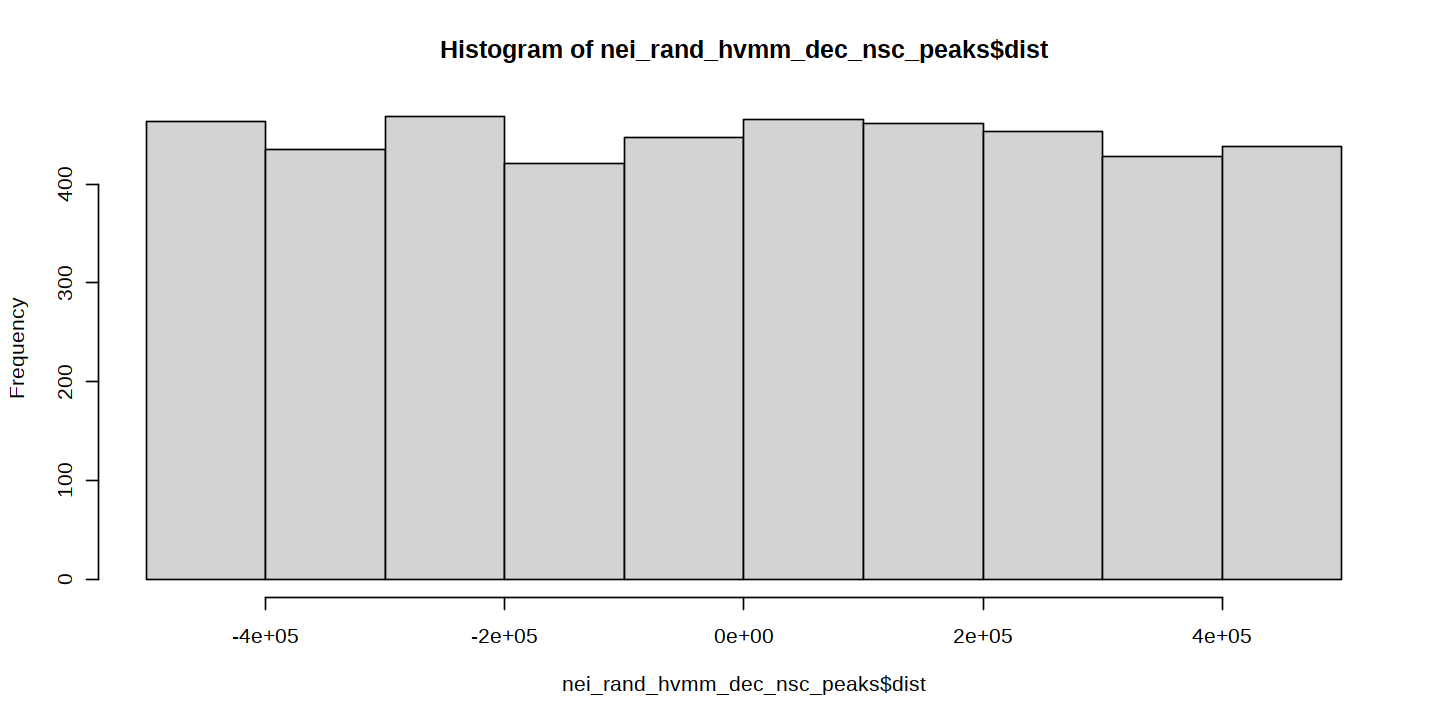

In [486]:
nei_rand_hvmm_dec_nsc_peaks <- gintervals.neighbors(dplyr::mutate(rand_hvm, strand = 1, intervalID = 1:nrow(rand_hvm)), dplyr::mutate(mcp[mcp$peak_name %in% nsc_peaks_all,], strand = 1),
                                                    mindist = -RAD, maxdist = RAD, maxneighbors = 1e+6)

hist(nei_rand_hvmm_dec_nsc_peaks$dist)

In [487]:
bins <- seq(-5e+5, 5e+5, l = 201)
tbl_hvmm_inc <- table(cut(nei_hvmm_inc_nsc_peaks$dist, bins))
tbl_hvmm_dec <- table(cut(nei_hvmm_dec_nsc_peaks$dist, bins))

In [365]:
png('./output/hic/figs/nsc_peak_den_around_diff_ins_regions_by_rad.png', h = 1200, w = 300)
# KSM <- 20
par(las = 2, mfrow = c(4,1), mar = c(9,9,1,1), cex.lab = 2, cex.axis = 1.5, cex.main = 3)
vvv <- sapply(c(5,10,20, 30), function(KSM) {
    tbl_hvmm_inc_sm <- zoo::rollmean(tbl_hvmm_inc, k = KSM, na.pad = T)
    tbl_hvmm_dec_sm <- zoo::rollmean(tbl_hvmm_dec, k = KSM, na.pad = T)
    
    tbl_inc1 <- tbl_hvmm_inc_sm/sum(tbl_hvmm_inc_sm, na.rm = T)
    tbl_dec1 <- tbl_hvmm_dec_sm/sum(tbl_hvmm_dec_sm, na.rm = T)
    # print(tbl_inc1)
    # print(tbl_dec1)
    plot(1:length(tbl_hvmm_inc_sm), tbl_inc1, col = 'purple', ylim = c(0,max(c(tbl_inc1, tbl_dec1), na.rm = T)), 
         type=  'l', xlab = '', xaxt = 'n', ylab = '', 
         # main = glue::glue('k = {KSM}')
        )
    inds <- seq(1, length(tbl_hvmm_inc_sm)+1, 20)
    axis(1, at = inds, labels = bins[inds])
    title(xlab = 'Distance [bp]', line = 7)
    title(ylab = glue::glue('Smoothed density\nk = {KSM}'), line = 5)
    lines(1:length(tbl_hvmm_dec_sm), tbl_dec1, col = 'orange')
    legend('bottomright', col = c('purple', 'orange', 'black'), lwd = rep(2,3), lty = c(1,1,2), legend = c('Shallowing', 'Deepening', 'mean'))
    lines(2e+2*c(-1,1), rep(mean(tbl_dec1, na.rm = T), 2), lty = 2, lwd = 2, col = 'black')
    
})
dev.off()
# inds <- seq(1, length(tbl_hvmm_dec_sm), 20)
# axis(1, at = inds, labels = bins[inds])

png 
  2

In [488]:
bins <- seq(-1, 5e+5, l = 11)
tbl_hvmm_inc <- table(cut(abs(nei_hvmm_inc_nsc_peaks$dist), bins))
tbl_hvmm_dec <- table(cut(abs(nei_hvmm_dec_nsc_peaks$dist), bins))
tbl_rand_hvmm <- table(cut(abs(nei_rand_hvmm_dec_nsc_peaks$dist), bins))

In [489]:
### Count neighboring peaks closer than 100kbp per interval category
v1 <- table(nei_hvmm_inc_nsc_peaks$intervalID[abs(nei_hvmm_inc_nsc_peaks$dist) <= 1e+5])
v2 <- table(nei_hvmm_dec_nsc_peaks$intervalID[abs(nei_hvmm_dec_nsc_peaks$dist) <= 1e+5])
v3 <- table(nei_rand_hvmm_dec_nsc_peaks$intervalID[abs(nei_rand_hvmm_dec_nsc_peaks$dist) <= 1e+5])
v1[as.character(setdiff(1:nrow(hvmm_inc), as.numeric(names(v1))))] <- 0
v2[as.character(setdiff(1:nrow(hvmm_dec), as.numeric(names(v2))))] <- 0
v3[as.character(setdiff(1:nrow(rand_hvm), as.numeric(names(v3))))] <- 0
dfv <- as.data.frame(tibble::enframe(c(setNames(rep('inc', length(v1)), v1),
                       setNames(rep('dec', length(v2)), v2),
                       setNames(rep('rand', length(v3)), v3)
                      ), name = 'intervalID', value = 'type'))
dfv[,'intervalID'] <- as.numeric(dfv[,'intervalID'])

In [490]:
library(vioplot)

Loading required package: sm

Package 'sm', version 2.2-5.7: type help(sm) for summary information

Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




In [159]:
# options(repr.plot.width = 7)
# boxplot(intervalID ~ type, data = dfv)

## Fig S5B

In [495]:
options(repr.plot.width = 7)
png('./output/hic/figs/interval_type_num_nei_100kbp_boxplot.png', h = 400, w = 500)
par(mfrow = c(1,1), cex.lab = 1.5, cex.axis = 1.5, mar = c(6,5,2,1))
vioplot(intervalID ~ type, data = dfv, xlab = '', names = rep('', 3), ylab = 'Number of neighbors within 100kbp', col = c('purple','orange', 'darkgray'))
axis(1, at = 1:3,padj = rep(0.5, 3), labels = c('Shallowing\ninsulation', 'Deepening\ninsulation', 'Random'))
title(xlab = 'Interval type', line = 4)
dev.off()

png 
  2

In [211]:
ks.test(v1, v2, alternative = 'less')

ks.test(v1, v3, alternative = 'less')

ks.test(v2, v3, alternative = 'greater')

tbl_rand_hvmm

tbl_hvmm_inc

tbl_hvmm_dec

errb1 <- sqrt(tbl_hvmm_inc)/sum(tbl_hvmm_inc)
errb2 <- sqrt(tbl_hvmm_dec)/sum(tbl_hvmm_dec)

y1 <- tbl_hvmm_inc/sum(tbl_hvmm_inc)
y2 <- tbl_hvmm_dec/sum(tbl_hvmm_dec)
dy1p <- y1 + errb1
dy1m <- y1 - errb1
dy2p <- y2 + errb2
dy2m <- y2 - errb2

png('./output/hic/figs/test_barp.png')
par(las = 2, mar = c(10,4,2,2))

barplot(y1, col = rgb(1,0,0,0.5), ylim = c(0,0.15), width = 8.25/10)
# rrr <- sapply(seq_along(errb1), function(i) lines(rep(i,2), c(dy1p[[i]], dy1m[[i]]), col = rgb(1,0,0)))
rrr <- sapply(seq_along(errb1), function(i) arrows(i-0.5,dy1p[[i]], i-0.5, dy1m[[i]], angle=90, code=3, length=0.1, col = rgb(1,0,0)))


barplot(y2, add = T, col = rgb(0,0,1,0.5), width = 8.25/10)
# rrr <- sapply(seq_along(errb2), function(i) lines(rep(i-0.5,2), c(dy2p[[i]], dy2m[[i]]), col = rgb(0,0,1)))
rrr <- sapply(seq_along(errb2), function(i) arrows(i-0.5,dy2p[[i]], i-0.5, dy2m[[i]], angle=90, code=3, length=0.1, col = rgb(0,0,1)))
lines(c(-1,11), rep(0.1,2), lwd = 2, lty = 2)
dev.off()

(tbl_hvmm_inc/sum(tbl_hvmm_inc) - tbl_hvmm_dec/sum(tbl_hvmm_dec))/sqrt(errb1**2 + errb2**2)

In [792]:
# # png('./output/hic/figs/shallowing_vs_deepening_diff_hic_regions.png', h = 350, w = 1050)
# par(mfrow = c(1,3), cex.main = 2.5, cex.lab = 2, cex.axis = 1.5, mar = c(5,6,4,1))
# plot(den_inc$x, den_inc$y, col = 'red', ylab = 'Density', xlab = 'Distance from region [bp]', type = 'l', lwd = 2, main = glue::glue('Density of NSC peaks {RAD} around\ndifferential insulation regions'))
# lines(den_dec$x, den_dec$y, col = 'blue', lwd = 2)
# legend('bottom', legend = c('Shallowing', 'Deepening'), col = c('red', 'blue'), lwd = rep(2,2), cex = 1.5)
# hist(nei_hvmm_inc_nsc_peaks$dist, 150, main = 'Shallowing regions', xlab = 'Distance from region [bp]', ylab = '# regions')
# hist(nei_hvmm_dec_nsc_peaks$dist, 150, main = 'Deepening regions', xlab = 'Distance from region [bp]', ylab = '# regions')
# # dev.off()

# a_legc_avg_cl_ct <- t(tgs_matrix_tapply(tgs_matrix_tapply(t(a_legc), km_a_legc$cluster, mean), mcmd$cell_type, mean))
# a_legc_avg_ct <- t(tgs_matrix_tapply(a_legc, mcmd$cell_type, mean))

# nsc_peak_clusters <- intersect(which(a_legc_avg_cl_ct[,'NSC'] - rowMaxs(subset(a_legc_avg_cl_ct, select = -NSC)) >= 0.1), peak_clust_var)
# ipc_peak_clusters <- intersect(which(rowMeans(a_legc_avg_cl_ct[,c('IPC', 'IPC_cyc')]) - rowMaxs(subset(a_legc_avg_cl_ct, select = -c(IPC, IPC_cyc))) >= 0.1), peak_clust_var)

# neuro_peak_clusters <- intersect(which(rowMaxs(a_legc_avg_cl_ct[,c('SCPN', 'CthPN', 'CPN_L5_6', 'CPN_L2-3')]) - rowMaxs(subset(a_legc_avg_cl_ct, select = -c(SCPN, CthPN, CPN_L5_6, `CPN_L2-3`))) >= 0.1), peak_clust_var)

# astro_peak_clusters <- intersect(which(a_legc_avg_cl_ct[,c('Astrocytes')] - rowMaxs(subset(a_legc_avg_cl_ct, select = -c(Astrocytes))) > 0), peak_clust_var)

# var_peaks <- rownames(a_legc)[km_a_legc$cluster %in% peak_clust_var]

In [98]:
make_canonical <- function(intervs) {
    intervs$intervalID <- 1:nrow(intervs)
    intervs_c <- gintervals.canonic(intervs)
    intervs_c$intervalID_c <- 1:nrow(intervs_c)
    # print(head(intervs_c))
    nei_intervs_c <- gintervals.neighbors(intervs, intervs_c, mindist = 0, maxdist = 0, maxneighbors = 1)
    # print(head(nei_intervs_c))
    intervs_n <- intervs[unique(nei_intervs_c$intervalID[!duplicated(nei_intervs_c$intervalID_c)]),]
    return(intervs_n)
}

In [99]:
cond <- !(mcp$peak_name %in% prom_peaks$peak_name)
cond2 <- mcp$peak_name %in% var_peaks

In [447]:
# nsc_peaks <- dplyr::mutate(mcp[which(a_legc_avg_ct[,'NSC'] >= -15.5 & cond),], type = 'nsc_peak')
# ipc_peaks <- dplyr::mutate(mcp[which(rowMaxs(a_legc_avg_ct[,ipc_cts]) >= -15.5 & cond),], type = 'ipc_peak')
# neuro_peaks <- dplyr::mutate(mcp[which(rowMaxs(a_legc_avg_ct[,neuro_cts]) >= -15.5& cond),], type = 'neuro_peak')
# astro_peaks <- dplyr::mutate(mcp[which(a_legc_avg_ct[,'Astrocytes'] >= -15.5 & cond),], type = 'astro_peak')

In [448]:
# nsc_peaks <- dplyr::mutate(mcp[which(km_a_legc$cluster %in% nsc_peak_clusters & cond),], type = 'nsc_peak')
# ipc_peaks <- dplyr::mutate(mcp[which(km_a_legc$cluster %in% ipc_peak_clusters & cond),], type = 'ipc_peak')
# neuro_peaks <- dplyr::mutate(mcp[which(km_a_legc$cluster %in% neuro_peak_clusters & cond),], type = 'neuro_peak')
# astro_peaks <- dplyr::mutate(mcp[which(km_a_legc$cluster %in% astro_peak_clusters & cond),], type = 'astro_peak')

In [210]:
nsc_peaks_n <- make_canonical(mcp[mcp$peak_name %in% nsc_peaks,])

In [211]:
nsc_asc_peaks_n <- make_canonical(mcp[mcp$peak_name %in% nsc_asc_peaks,])
nsc_desc_peaks_n <- make_canonical(mcp[mcp$peak_name %in% nsc_desc_peaks,])

In [212]:
ipc_peaks_n <- make_canonical(mcp[mcp$peak_name %in% ipc_peaks,])

In [213]:
neuro_peaks_n <- make_canonical(mcp[mcp$peak_name %in% neuro_peaks,])

In [214]:
astro_peaks_n <- make_canonical(mcp[mcp$peak_name %in% astro_peaks,])

In [215]:
SHIFT_DIAMOND <- (1e+4 - 3e+2)/2
ct_tss_all <- dplyr::mutate(rbind(nsc_tss, ipc_tss, neuro_tss, astro_tss), start = start - SHIFT_DIAMOND, end = end + SHIFT_DIAMOND)
# ct_peaks_all <- dplyr::mutate(rbind(nsc_peaks, ipc_peaks, neuro_peaks), start = start - SHIFT_DIAMOND, end = end + SHIFT_DIAMOND)

In [216]:
table(ct_tss_all$type)


astro_tss   ipc_tss neuro_tss   nsc_tss 
      719       818       561       907 

In [217]:
ct_tss_all_no_shift <- rbind(nsc_tss, ipc_tss, neuro_tss, astro_tss)

In [218]:
nei_peaks_tss_astro <- gintervals.neighbors(dplyr::mutate(astro_peaks_n, strand = 1), dplyr::mutate(ct_tss_all_no_shift, strand = 1), mindist = -1e+6, maxdist = 1e+6, maxneighbors = 1e+6)

In [219]:
nei_peaks_tss_nsc <- gintervals.neighbors(dplyr::mutate(nsc_peaks_n, strand = 1), dplyr::mutate(ct_tss_all_no_shift, strand = 1), mindist = -1e+6, maxdist = 1e+6, maxneighbors = 1e+6)

In [220]:
nei_peaks_tss_ipc <- gintervals.neighbors(dplyr::mutate(ipc_peaks_n, strand = 1), dplyr::mutate(ct_tss_all_no_shift, strand = 1), mindist = -1e+6, maxdist = 1e+6, maxneighbors = 1e+6)

In [482]:
# 2e+3/(tbl_peaks_n_all[[gsub('_tss', '_peaks', peak_type)]]/sum(.misha$ALLGENOME[[1]]$end))

# unique(nei_peaks_tss_astro$type)

# 2e+3*tbl_peaks_n_all[gsub('_tss', '_peaks', unique(nei_peaks_tss_astro$type))]/sum(.misha$ALLGENOME[[1]]$end)

# tbl_peaks_n_all/sum(.misha$ALLGENOME[[1]]$end)

# 1e+6/500

# xxx <- plot_ct_nei_distance_distribution(nei_peaks_tss_astro, 'astro_tss', 'Astrocytes', bins = bins)

# head(xxx[[1]])

# quantile(xxx[[2]], (0:10)/10)

# plot(1:length(xxx[[2]]), xxx[[2]])

# quantile(xxx[[2]], (0:10)/10)

# quantile(xxx[[2]], (0:10)/10)

# quantile(xxx[[2]], (0:10)/10)

In [233]:
plot_ct_nei_distance_distribution <- function(nei_df, tss_type, peak_type, cell_type, bins, K = 40) {
    x <- nei_df$dist[nei_df$type == tss_type]
    xcut <- cut(x, breaks = bins)
    xc_tbl <- as.numeric(table(xcut))
    xc_tbl_norm <- log2((1+xc_tbl)/(1+mean(xc_tbl, na.rm = T)))
    # print(signif(xc_tbl_norm, 1))
    xc_tbl_rm <- zoo::rollmean(xc_tbl_norm, k = K, na.pad = T)
    # print(signif(xc_tbl_rm, 1))
    xcoords <- (head(bins, -1) + tail(bins, -1))/2
    return(lines(xcoords, xc_tbl_rm, col = col_key[[cell_type]], lwd = 2, lty = 1))
    # return(lines(xcoords, xc_tbl_rm/(diff(head(bins, 2))*K), col = col_key[[cell_type]], lwd = 2, lty = 1))
    # return(list(xcoords, xc_tbl))
}

## Fig 5D, Fig 5E

In [234]:
options(repr.plot.width = 12)
options(repr.plot.height = 6)
# png('./output/hic/figs/ct_tsss_near_astro_nsc_peaks.png', h = 450, w = 1350, res = 100)
pdf('./output/hic/figs/ct_tsss_near_astro_nsc_peaks.pdf', h = 450/71, w = 1350/71)
par(mfrow = c(1,3), cex.axis = 2, cex.lab = 2, mar = c(5,5,4,1), cex.main = 2)
bins <- seq(-0.5e+6, 0.5e+6, l = 500)
plot(0, xlim = c(-5.5e+5, max(bins)), col = 'white', , xaxt = 'n',
     ylim = c(-0.6,1), 
     main = 'type-specific TSS density\nnear Astrocyte peaks', ylab = 'Smoothed log-fold enrichment', xlab = 'bp from peak')
grid()
plot_ct_nei_distance_distribution(nei_peaks_tss_astro, 'ipc_tss', 'astro_peaks', 'IPC', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_astro, 'nsc_tss', 'astro_peaks', 'NSC', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_astro, 'astro_tss', 'astro_peaks', 'Astrocytes', bins = bins)
legend('topleft', legend = c(paste0('IPC TSSs\nn = ', nrow(ipc_tss), '\n'), paste0('NSC TSSs\nn = ', nrow(nsc_tss), '\n'), 
                             paste0('Astro TSSs\nn = ', nrow(astro_tss), '\n')),
       col = col_key[c('IPC', 'NSC', 'Astrocytes')], lwd = 2, lty = 1, cex = 1.75)
axis(1, at = c(-4e+5, 0, 4e+5), labels = c('-400kbp', '0', '400kbp'))
text(-4e+5, 2.83, labels = paste0('n_peaks = ', nrow(astro_peaks_n)), adj = c(0,0), cex = 1.5)
# plot_ct_nei_distance_distribution(nei_peaks_tss_astro, 'neuro_tss', 'CthPN', bins = bins)

plot(0, xlim = c(min(bins), max(bins)), col = 'white', , xaxt = 'n',
     ylim = c(-0.6,1),
     main = 'type-specific TSS density\nnear NSC peaks', ylab = 'Smoothed log-fold enrichment', xlab = 'bp from peak')
grid()
plot_ct_nei_distance_distribution(nei_peaks_tss_nsc, 'ipc_tss', 'nsc_peaks', 'IPC', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_nsc, 'astro_tss', 'nsc_peaks', 'Astrocytes', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_nsc, 'nsc_tss', 'nsc_peaks', 'NSC', bins = bins)
# legend('topleft', legend = c(paste0('IPC TSSs\nn = ', nrow(ipc_tss)), paste0('NSC TSSs\nn = ', nrow(nsc_tss)), 
#                              paste0('Astro TSSs\nn = ', nrow(astro_tss))), col = col_key[c('IPC', 'NSC', 'Astrocytes')], lwd = 2, lty = 1, cex = 1.8)
axis(1, at = c(-4e+5, 0, 4e+5), labels = c('-400kbp', '0', '400kbp'))
text(-4e+5, 2.3, labels = paste0('n_peaks = ', nrow(nsc_peaks_n)), adj = c(0,0), cex = 1.5)
# plot_ct_nei_distance_distribution(nei_peaks_tss_astro, 'neuro_tss', 'CthPN', bins = bins)

plot(0, xlim = c(min(bins), max(bins)), col = 'white', , xaxt = 'n',
     ylim = c(-0.6,1), 
     main = 'type-specific TSS density\nnear IPC peaks', ylab = 'Smoothed log-fold enrichment', xlab = 'bp from peak')
grid()
plot_ct_nei_distance_distribution(nei_peaks_tss_ipc, 'ipc_tss', 'ipc_peaks', 'IPC', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_ipc, 'nsc_tss', 'ipc_peaks','NSC', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_ipc, 'astro_tss', 'ipc_peaks','Astrocytes', bins = bins)
# legend('topleft', legend = c(paste0('IPC TSSs\nn = ', nrow(ipc_tss)), paste0('NSC TSSs\nn = ', nrow(nsc_tss)),
#                              paste0('Astro TSSs\nn = ', nrow(astro_tss))), col = col_key[c('IPC', 'NSC', 'Astrocytes')], lwd = 2, lty = 1, cex = 1.8)
axis(1, at = c(-4e+5, 0, 4e+5), labels = c('-400kbp', '0', '400kbp'))
text(-4e+5, 2.3, labels = paste0('n_peaks = ', nrow(ipc_peaks_n)), adj = c(0,0), cex = 1.5)
dev.off()

png 
  2

In [150]:
peaks_n_all <- dplyr::bind_rows(dplyr::mutate(nsc_peaks_n, peak_type = 'nsc_peaks'), 
                                dplyr::mutate(ipc_peaks_n, peak_type = 'ipc_peaks'),
                                dplyr::mutate(neuro_peaks_n, peak_type = 'neuro_peaks'),
                                dplyr::mutate(astro_peaks_n, peak_type = 'astro_peaks'))

In [151]:
tbl_peaks_n_all <- table(peaks_n_all$peak_type)

In [152]:
nei_peaks_tss_all <- gintervals.neighbors(dplyr::mutate(ct_tss_all_no_shift, strand = 1), dplyr::mutate(peaks_n_all, strand = 1), mindist = -1e+6, maxdist = 1e+6, maxneighbors = 1e+6)

In [153]:
plot_ct_nei_distance_distribution <- function(nei_df, tss_type, peak_type, cell_type, bins, K = 40) {
    x <- nei_df$dist[nei_df$type == tss_type & nei_df$peak_type == peak_type]
    xcut <- cut(x, breaks = bins)
    xc_tbl <- as.numeric(table(xcut))
    xc_tbl_norm <- log2((1 + xc_tbl)/(1+mean(xc_tbl, na.rm = T)))
    xc_tbl_rm <- zoo::rollmean(xc_tbl_norm, k = K, na.pad = T)
    xcoords <- (head(bins, -1) + tail(bins, -1))/2
    return(lines(xcoords, xc_tbl_rm, col = col_key[[cell_type]], lwd = 2, lty = 1))
    # return(lines(xcoords, xc_tbl_rm/(diff(head(bins, 2))*K), col = col_key[[cell_type]], lwd = 2, lty = 1))
    # return(list(xcoords, xc_tbl))
}

In [156]:
options(repr.plot.width = 12)
options(repr.plot.height = 6)
# png('./output/hic/figs/ct_peaks_near_astro_nsc_tsss_new.png', h = 450, w = 1350, res = 100)
pdf('./output/hic/figs/ct_peaks_near_astro_nsc_tsss_new.pdf', h = 450/71, w = 1350/71)
par(mfrow = c(1,3), cex.axis = 2, cex.lab = 2, mar = c(5,5,4,1), cex.main = 2)
bins <- seq(-0.5e+6, 0.5e+6, l = 500)
plot(0, xlim = c(-4.5e+5, max(bins)), col = 'white', xaxt = 'n',
     ylim = c(-0.6,1), 
     main = 'type-specific peak density\nnear Astrocyte TSSs', ylab = 'Smoothed log-fold enrichment', xlab = 'bp from TSS')
grid()
plot_ct_nei_distance_distribution(nei_peaks_tss_all, 'astro_tss', 'astro_peaks', 'Astrocytes', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_all, 'astro_tss', 'nsc_peaks', 'NSC', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_all, 'astro_tss', 'ipc_peaks','IPC', bins = bins)
legend('topleft', legend = c(paste0('IPC peaks\nn = ', nrow(ipc_peaks_n), '\n'), paste0('NSC peaks\nn = ', nrow(nsc_peaks_n), '\n'), 
                              paste0('Astro peaks\nn = ', nrow(astro_peaks_n), '\n')), col = col_key[c('IPC', 'NSC', 'Astrocytes')], lwd = 2, lty = 1, cex = 1.75)
text(-4e+5, 2.83, labels = paste0('n_TSSs = ', nrow(astro_tss)), adj = c(0,0), cex = 1.5)
axis(1, at = c(-4e+5, 0, 4e+5), labels = c('-400kbp', '0', '400kbp'))
# plot_ct_nei_distance_distribution(nei_peaks_tss_astro, 'neuro_tss', 'CthPN', bins = bins)

plot(0, xlim = c(-4.5e+5, max(bins)), col = 'white', xaxt = 'n',
     ylim = c(-0.6,1), 
     main = 'type-specific peak density\nnear NSC TSSs', ylab = 'Smoothed log-fold enrichment', xlab = 'bp from TSS')
grid()
plot_ct_nei_distance_distribution(nei_peaks_tss_all, 'nsc_tss', 'astro_peaks', 'Astrocytes', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_all, 'nsc_tss', 'nsc_peaks', 'NSC', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_all, 'nsc_tss', 'ipc_peaks','IPC', bins = bins)
# legend('topleft', legend = c(paste0('IPC peaks\nn = ', nrow(ipc_peaks_n), '\n'), paste0('NSC peaks\nn = ', nrow(nsc_peaks_n), '\n'), 
#                               paste0('Astro peaks\nn = ', nrow(astro_peaks_n), '\n')), col = col_key[c('IPC', 'NSC', 'Astrocytes')], lwd = 2, lty = 1, cex = 1.8)
axis(1, at = c(-4e+5, 0, 4e+5), labels = c('-400kbp', '0', '400kbp'))
text(-4e+5, 2.3, labels = paste0('n_TSSs = ', nrow(nsc_tss)), adj = c(0,0), cex = 1.5)
# plot_ct_nei_distance_distribution(nei_peaks_tss_astro, 'neuro_tss', 'CthPN', bins = bins)

plot(0, xlim = c(-4.5e+5, max(bins)), col = 'white', xaxt = 'n',
     ylim = c(-0.6,1),
     main = 'type-specific peak density\nnear IPC TSSs', ylab = 'Smoothed log-fold enrichment', xlab = 'bp from TSS')
grid()
plot_ct_nei_distance_distribution(nei_peaks_tss_all, 'ipc_tss', 'astro_peaks', 'Astrocytes', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_all, 'ipc_tss', 'nsc_peaks', 'NSC', bins = bins)
plot_ct_nei_distance_distribution(nei_peaks_tss_all, 'ipc_tss', 'ipc_peaks', 'IPC', bins = bins)
# legend('topleft', legend = c(paste0('IPC peaks\nn = ', nrow(ipc_peaks_n), '\n'), paste0('NSC peaks\nn = ', nrow(nsc_peaks_n), '\n'), 
#                               paste0('Astro peaks\nn = ', nrow(astro_peaks_n), '\n')), col = col_key[c('IPC', 'NSC', 'Astrocytes')], lwd = 2, lty = 1, cex = 1.8)
axis(1, at = c(-4e+5, 0, 4e+5), labels = c('-400kbp', '0', '400kbp'))
text(-4e+5, 2.3, labels = paste0('n_TSSs = ', nrow(ipc_tss)), adj = c(0,0), cex = 1.5)
dev.off()

png 
  2

In [468]:
# tbl_peaks_n_all

# length(astro_peaks)

# unique(nei_peaks_tss_astro$type)

# table(nei_peaks_tss_astro$type)
# table(nei_peaks_tss_astro$type)/sum(table(nei_peaks_tss_astro$type))
# table(ct_tss_all_no_shift$type)/sum(table(ct_tss_all_no_shift$type))

# table(nei_peaks_tss_nsc$type)
# table(nei_peaks_tss_nsc$type)/sum(table(nei_peaks_tss_nsc$type))
# table(ct_tss_all_no_shift$type)/sum(table(ct_tss_all_no_shift$type))

In [484]:
## Diamond intervals around E-P pairs

nei_peaks_tss_nsc <- gintervals.neighbors(nsc_peaks_n, ct_tss_all_no_shift, maxdist = 1e+6, maxneighbors = 1e+6)
nei_peaks_tss_ipc <- gintervals.neighbors(ipc_peaks_n, ct_tss_all_no_shift, maxdist = 1e+6, maxneighbors = 1e+6)
nei_peaks_tss_neuro <- gintervals.neighbors(neuro_peaks_n, ct_tss_all_no_shift, maxdist = 1e+6, maxneighbors = 1e+6)
nei_peaks_tss_astro <- gintervals.neighbors(astro_peaks_n, ct_tss_all_no_shift, maxdist = 1e+6, maxneighbors = 1e+6)

In [485]:
dim(nei_peaks_tss_astro)

[1] 3455   11

In [461]:
cols = setNames(col_key[c('IPC','NSC', 'Astrocytes', 'CthPN')], unique(nei_peaks_tss_astro$type))

In [462]:
cols

ipc_tss   nsc_tss astro_tss neuro_tss 
"#0000CD" "#00C5CD" "#C4658D" "#8B4726"

In [453]:
options(repr.plot.height = 14)
options(repr.plot.width = 14)

In [460]:
unique(nei_peaks_tss_astro$type)

[1] "ipc_tss"   "nsc_tss"   "astro_tss" "neuro_tss"

In [465]:
png('./output/mcatac/figs/ecdf_type_specific_peaks_to_type_specific_tsss.png', h = 800, w = 800, res = 100)
par(mfrow = c(2,2), mar = c(4,5,2,1.5), cex.axis = 1.5, cex.lab = 2, cex.main = 1.5)
plot(0, col = 'white', xlim = c(0,1e+6), ylim = c(0,1), main = 'Astro peaks vs type-specific genes', ylab = 'ECDF', xlab = 'bp', col.main = col_key['Astrocytes'])
ttt <- sapply(unique(nei_peaks_tss_astro$type), function(ty) plot(ecdf(nei_peaks_tss_astro$dist[nei_peaks_tss_astro$type == ty]), add = T, do.points = F, col = cols[ty], lwd = 2))
legend('bottomright', legend = unique(nei_peaks_tss_astro$type), col = cols[unique(nei_peaks_tss_astro$type)], cex = 1, lwd = rep(1,4))
plot(0, col = 'white', xlim = c(0,1e+6), ylim = c(0,1), main = 'NSC peaks vs type-specific genes', ylab = 'ECDF', xlab = 'bp', col.main = col_key['NSC'])
ttt <- sapply(unique(nei_peaks_tss_nsc$type), function(ty) plot(ecdf(nei_peaks_tss_nsc$dist[nei_peaks_tss_nsc$type == ty]), add = T, do.points = F, col = cols[ty], lwd = 2))
legend('bottomright', legend = unique(nei_peaks_tss_astro$type), col = cols[unique(nei_peaks_tss_astro$type)], cex = 1, lwd = rep(1,4))
plot(0, col = 'white', xlim = c(0,1e+6), ylim = c(0,1), main = 'IPC peaks vs type-specific genes', ylab = 'ECDF', xlab = 'bp', col.main = col_key['IPC'])
ttt <- sapply(unique(nei_peaks_tss_ipc$type), function(ty) plot(ecdf(nei_peaks_tss_ipc$dist[nei_peaks_tss_ipc$type == ty]), add = T, do.points = F, col = cols[ty], lwd = 2))
legend('bottomright', legend = unique(nei_peaks_tss_astro$type), col = cols[unique(nei_peaks_tss_astro$type)], cex = 1, lwd = rep(1,4))
plot(0, col = 'white', xlim = c(0,1e+6), ylim = c(0,1), main = 'Neuron peaks vs type-specific genes', ylab = 'ECDF', xlab = 'bp', col.main = col_key['CthPN'])
ttt <- sapply(unique(nei_peaks_tss_neuro$type), function(ty) plot(ecdf(nei_peaks_tss_neuro$dist[nei_peaks_tss_neuro$type == ty]), add = T, do.points = F, col = cols[ty], lwd = 2))
legend('bottomright', legend = unique(nei_peaks_tss_astro$type), col = cols[unique(nei_peaks_tss_astro$type)], cex = 1, lwd = rep(1,4))
dev.off()

png 
  2

## Astrocyte peak analysis

In [305]:
# ds <- seq(0, 10e+5, 10e+4)
# nei_hvm_inc_ct_peaks_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(dplyr::mutate(hvmm_inc, intervalID = 1:nrow(hvmm_inc)), ct_peaks, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))
# nei_hvm_dec_ct_peaks_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(dplyr::mutate(hvmm_dec, intervalID = 1:nrow(hvmm_dec)), ct_peaks, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))

# ds <- seq(0, 10e+5, 10e+4)
# nei_hvm_inc_ct_peaks_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(dplyr::mutate(hvmm_inc, intervalID = 1:nrow(hvmm_inc)), peaks_n_all, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))
# nei_hvm_dec_ct_peaks_ls <- lapply(tail(seq_along(ds), -1), function(i) gintervals.neighbors(dplyr::mutate(hvmm_dec, intervalID = 1:nrow(hvmm_dec)), peaks_n_all, mindist = ds[[i-1]], maxdist = ds[[i]], maxneighbors = 1e+6))

# pheatmap::pheatmap(sapply(seq_along(nei_hvm_inc_ct_peaks_ls), function(i) {
#     tbl1 <- table(nei_hvm_inc_ct_peaks_ls[[i]]$type)[names(table(ct_peaks$type))]/nrow(hvmm_inc)/table(ct_peaks$type)
#     tbl2 <- table(nei_hvm_dec_ct_peaks_ls[[i]]$type)[names(table(ct_peaks$type))]/nrow(hvmm_dec)/table(ct_peaks$type)
#     # print(tbl1)
#     # print(tbl2)
#     return(log2(tbl1/tbl2))
# }), cluster_cols =F, cluster_rows = F, col = colorRampPalette(c('blue3', 'white', 'red3'))(100), breaks = seq(-2,2,l=101)
# )

# pheatmap::pheatmap(sapply(seq_along(nei_hvm_inc_ct_peaks_ls), function(i) {
#     tbl1 <- table(nei_hvm_inc_ct_peaks_ls[[i]]$peak_type)[names(table(peaks_n_all$peak_type))]/nrow(hvmm_inc)/table(peaks_n_all$peak_type)
#     tbl2 <- table(nei_hvm_dec_ct_peaks_ls[[i]]$peak_type)[names(table(peaks_n_all$peak_type))]/nrow(hvmm_dec)/table(peaks_n_all$peak_type)
#     # print(tbl1)
#     # print(tbl2)
#     return(log2(tbl1/tbl2))
# }), cluster_cols =F, cluster_rows = F, col = colorRampPalette(c('blue3', 'white', 'red3'))(100), breaks = seq(-2,2,l=101)
# )

In [845]:
nei_hvm_inc_ct_peaks <- gintervals.neighbors(dplyr::mutate(hvmm_inc, intervalID = 1:nrow(hvmm_inc)),
                                             dplyr::rename(peaks_n_all, peak_name2 = peak_name), mindist = 0, maxdist = 5e+5, maxneighbors = 1e+6)

nei_hvm_dec_ct_peaks <- gintervals.neighbors(dplyr::mutate(hvmm_dec, intervalID = 1:nrow(hvmm_dec)),
                                             dplyr::rename(peaks_n_all, peak_name2 = peak_name), mindist = 0, maxdist = 5e+5, maxneighbors = 1e+6)

In [246]:
nei_ct_peaks_ct_peaks <- gintervals.neighbors(dplyr::rename(peaks_n_all, peak_name1 = peak_name, peak_type1 = peak_type),
                                              dplyr::rename(peaks_n_all, peak_name2 = peak_name, peak_type2 = peak_type), 
                                              mindist = 0, maxdist = 5e+4, maxneighbors = 1e+6)
nei_ct_peaks_ct_peaks <- nei_ct_peaks_ct_peaks[nei_ct_peaks_ct_peaks$peak_name1 != nei_ct_peaks_ct_peaks$peak_name2,]

nei_ct_peaks_ct_peaks$interaction <- gsub('_peaks', '', stringr::str_c(nei_ct_peaks_ct_peaks$peak_type1, nei_ct_peaks_ct_peaks$peak_type2, sep = '-'))

In [251]:
nei_ct_peaks_ct_peaks_1M <- gintervals.neighbors(dplyr::rename(peaks_n_all, peak_name1 = peak_name, peak_type1 = peak_type),
                                              dplyr::rename(peaks_n_all, peak_name2 = peak_name, peak_type2 = peak_type), 
                                              mindist = 0, maxdist = 1e+6, maxneighbors = 1e+6)
nei_ct_peaks_ct_peaks_1M <- nei_ct_peaks_ct_peaks_1M[nei_ct_peaks_ct_peaks_1M$peak_name1 != nei_ct_peaks_ct_peaks_1M$peak_name2,]

nei_ct_peaks_ct_peaks_1M$interaction <- gsub('_peaks', '', stringr::str_c(nei_ct_peaks_ct_peaks_1M$peak_type1, nei_ct_peaks_ct_peaks_1M$peak_type2, sep = '-'))

In [247]:
nei_ct_peaks2_combs_df <- dplyr::filter(expand.grid(unique(nei_ct_peaks_ct_peaks$interaction), unique(nei_ct_peaks_ct_peaks$interaction)), Var1 %in% c('astro-astro', 'ipc-ipc', 'nsc-nsc', 'neuro-neuro') & (Var1 != Var2))
nei_ct_peaks2_combs_df <- dplyr::filter(nei_ct_peaks2_combs_df, unlist(purrr::map(stringr::str_split(nei_ct_peaks2_combs_df$Var1, '-'),1)) == unlist(purrr::map(stringr::str_split(nei_ct_peaks2_combs_df$Var2, '-'),1))  | 
                            unlist(purrr::map(stringr::str_split(nei_ct_peaks2_combs_df$Var1, '-'),1)) == unlist(purrr::map(stringr::str_split(nei_ct_peaks2_combs_df$Var2, '-'),2)))

In [248]:
# peak_gene_comb_df <- expand.grid(unique(df_all$gene_type), unique(df_all$peak_type), unique(df_all$peak_type)) %>% dplyr::filter(Var2 != Var3)

ks_test_nei_ct_peaks <- lapply(1:nrow(nei_ct_peaks2_combs_df), function(n) {t1 <- nei_ct_peaks2_combs_df[n,'Var1']; 
                                               t2 <- nei_ct_peaks2_combs_df[n,'Var2']; 
                                               df_all_t1_inds <- which(nei_ct_peaks_ct_peaks$interaction == t1);
                                               df_all_t2_inds <- which(nei_ct_peaks_ct_peaks$interaction == t2);
                                               suppressWarnings(ks.test(x = nei_ct_peaks_ct_peaks$dist[df_all_t1_inds],
                                                          y = nei_ct_peaks_ct_peaks$dist[df_all_t2_inds], alternative = 'greater'))})

In [249]:
names(ks_test_nei_ct_peaks) <- apply(nei_ct_peaks2_combs_df, 1, paste0, collapse = '_')

In [252]:
ks_test_nei_ct_peaks

$`nsc-nsc_nsc-neuro`

	Two-sample Kolmogorov-Smirnov test

data:  nei_ct_peaks_ct_peaks$dist[df_all_t1_inds] and nei_ct_peaks_ct_peaks$dist[df_all_t2_inds]
D^+ = 0.16251, p-value < 2.2e-16
alternative hypothesis: the CDF of x lies above that of y


$`neuro-neuro_nsc-neuro`

	Two-sample Kolmogorov-Smirnov test

data:  nei_ct_peaks_ct_peaks$dist[df_all_t1_inds] and nei_ct_peaks_ct_peaks$dist[df_all_t2_inds]
D^+ = 0.16746, p-value < 2.2e-16
alternative hypothesis: the CDF of x lies above that of y


$`nsc-nsc_nsc-ipc`

	Two-sample Kolmogorov-Smirnov test

data:  nei_ct_peaks_ct_peaks$dist[df_all_t1_inds] and nei_ct_peaks_ct_peaks$dist[df_all_t2_inds]
D^+ = 0.091443, p-value < 2.2e-16
alternative hypothesis: the CDF of x lies above that of y


$`ipc-ipc_nsc-ipc`

	Two-sample Kolmogorov-Smirnov test

data:  nei_ct_peaks_ct_peaks$dist[df_all_t1_inds] and nei_ct_peaks_ct_peaks$dist[df_all_t2_inds]
D^+ = 0.088806, p-value < 2.2e-16
alternative hypothesis: the CDF of x lies above that of y


$`

In [881]:
library(vioplot)

# png('./output/mcatac/figs/pairwise_dist_ct_peaks_vioplot.png', h =400, w = 700)
par(cex.axis = 1.5, cex.lab = 2, mar = c(12,7,2,1), las = 2)
vioplot(dist ~ interaction, data = nei_ct_peaks_ct_peaks, 
       ylab = '', xlab = '')
title(ylab = 'Distance [bp]', line = 5)
title(xlab = 'Peak type pairs', line = 9)
ttt <- sapply(seq(4.5,4.5+2*4,4), function(x) lines(rep(x,2), c(0,1e+7), lwd = 3))
# dev.off()

## Fig 5F

In [260]:
# png('./output/mcatac/figs/pairwise_dist_ct_peaks_boxplot.png', h =600, w = 700)
# pdf('./output/mcatac/figs/pairwise_dist_ct_peaks_boxplot.pdf', h =600/71, w = 700/71)

pdf('./output/mcatac/figs/pairwise_dist_ct_peaks_boxplot_1M.pdf', h =400/71, w = 500/71)

par(cex.axis = 1.5, cex.lab = 2, mar = c(12,7,2,1), las = 2)
boxplot(dist ~ interaction, data = nei_ct_peaks_ct_peaks_1M, 
       ylab = '', xlab = '')
title(ylab = 'Distance [bp]', line = 5)
title(xlab = 'Peak type pairs', line = 9)
ttt <- sapply(seq(4.5,4.5+2*4,4), function(x) lines(rep(x,2), c(0,1e+7), lwd = 3))
# text(1:length(unique(nei_ct_peaks_ct_peaks$interaction)), srt = 90,
#      # 45e+3 + 7500*(-0.5+runif(length(unique(nei_ct_peaks_ct_peaks$interaction)))) , 
#       45e+3, cex = 2,
#      labels = paste0(round(table(nei_ct_peaks_ct_peaks$interaction)/1e+3, 1), 'e+3'), col = 'red')
dev.off()

png 
  2

In [254]:
dev.off()

pdf 
  3

In [493]:
png('./output/mcatac/figs/nsc_astro_peaks_pairwise_distance_distribution.png', h = 450, w = 450)
par(cex.main = 1.5, cex.axis = 1.5, cex.lab = 1.5, mar = c(5,5,4,1))
plot(ecdf(nei_ct_peaks_ct_peaks$dist[nei_ct_peaks_ct_peaks$peak_type1 == 'astro_peaks' & nei_ct_peaks_ct_peaks$peak_type2 == 'astro_peaks']), lwd = 2, col = 'blue', do.points = F, 
     main = 'Pairwise distances between\nastrocyte-/NSC-specific peaks', ylab = 'ECDF', xlab = 'Distance [bp]')
plot(ecdf(nei_ct_peaks_ct_peaks$dist[nei_ct_peaks_ct_peaks$peak_type1 == 'nsc_peaks' & nei_ct_peaks_ct_peaks$peak_type2 == 'astro_peaks']), lwd = 2, add = T, col = 'orange', do.points = F)
plot(ecdf(nei_ct_peaks_ct_peaks$dist[nei_ct_peaks_ct_peaks$peak_type1 == 'nsc_peaks' & nei_ct_peaks_ct_peaks$peak_type2 == 'nsc_peaks']), lwd = 2, add = T, col = 'red', do.points = F)
legend('bottomright', legend = c('astro-astro', 'astro-nsc', 'nsc-nsc'), col = c('blue', 'orange', 'red'), lwd = rep(2,3), cex = 2)
dev.off()

png 
  2